# Quantitative Investment Pipeline
## A Factor-Driven Portfolio Construction System
**Donald | Python for Finance Project | 2024**

---

### Investment Universe
Ten assets across four economic characters: NVDA, TSLA, PLTR, GOOGL, MSFT (technology/AI growth), JPM (financial), JNJ (healthcare defensive), XOM (energy commodity), SPY (broad market benchmark), GLD (safe haven).

### Investment Thesis
A technology and AI-tilted portfolio with genuine diversification through defensive and commodity assets. The thesis holds that AI infrastructure and data analytics represent structural growth themes, while GLD, JNJ, and XOM provide uncorrelated returns that reduce portfolio volatility without proportionally reducing return.

### Pipeline Structure
- Block 1: Data Infrastructure and Return Analysis
- Block 2: Factor Model Construction
- Block 3: Portfolio Optimisation (MPT)
- Block 4: Monte Carlo Simulation
- Block 5: Risk Measurement (VaR)
- Block 6: Bayesian Dynamic Optimisation

### How This Notebook Is Structured
Each block follows the same pattern: a short **methodology** section framing the objective and approach, the **implementation** — code and outputs — and a closing **Findings & Interpretation** section that connects the results back to the investment thesis and carries any limitations forward into later blocks.

---

## Block 1 — Data Infrastructure and Return Analysis

### Objective
Establish the data foundation for the entire pipeline. Pull real price data for all ten assets, compute log returns, and test the normality assumption that underpins every subsequent model.

### Key Concepts
- **Log returns** are used because they are additive over time, symmetric, and connect directly to the GBM framework used in Block 4
- **The covariance matrix** is the mathematical foundation of diversification — low off-diagonal values between assets produce genuine risk cancellation when combined in a portfolio
- **Normality testing** is essential before modelling — if returns are not normally distributed, every downstream model that assumes normality will underestimate tail risk

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as scs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pylab import mpl

plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

print("Block 1 — Data Infrastructure and Return Analysis")
print("=" * 52)



Block 1 — Data Infrastructure and Return Analysis


In [5]:
# --- Assets ---
# Technology (growth/AI tilt): NVDA, TSLA, PLTR, GOOGL, MSFT
# Financial: JPM
# Healthcare defensive: JNJ
# Energy commodity: XOM
# Broad market benchmark: SPY
# Safe haven: GLD

tickers = ['NVDA', 'TSLA', 'PLTR', 'GOOGL', 'MSFT',
           'JPM', 'JNJ', 'XOM', 'SPY', 'GLD']

# Pull all price data
# 2015-2023: captures multiple market regimes
# COVID crash (2020), bull run (2021), rate shock (2022)
raw_full = yf.download(tickers, start='2015-01-01', end='2023-12-31')


# Select only the Close price for all tickers
# MultiIndex selection: first level = 'Close', returns a (days x 10) DataFrame
raw = raw_full['Close']

# Drop rows with missing data
# PLTR listed September 2020 — all earlier rows become NaN and are dropped here
raw.dropna(inplace=True)

print(f"Data shape: {raw.shape}")
print(f"Date range: {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"Trading days: {len(raw)}")
print(f"Columns: {list(raw.columns)}")
raw.head()

/var/folders/hw/f05t7jxs4x54rzgdwpldg__80000gn/T/ipykernel_33455/924041851.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_full = yf.download(tickers, start='2015-01-01', end='2023-12-31')
[*********************100%***********************]  10 of 10 completed


Data shape: (818, 10)
Date range: 2020-09-30 to 2023-12-29
Trading days: 818
Columns: ['GLD', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'PLTR', 'SPY', 'TSLA', 'XOM']


/var/folders/hw/f05t7jxs4x54rzgdwpldg__80000gn/T/ipykernel_33455/924041851.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw.dropna(inplace=True)


Ticker,GLD,GOOGL,JNJ,JPM,MSFT,NVDA,PLTR,SPY,TSLA,XOM
Date,,,,,,,,,,
2020-09-30,177.119995,72.589272,126.244690,82.601135,200.024017,13.472137,9.50,309.639526,143.003326,26.858463
2020-10-01,178.699997,73.693748,124.921860,83.201729,202.049637,13.555779,9.46,311.627380,149.386673,25.919624
2020-10-02,178.539993,72.093971,124.006065,83.991112,196.086853,13.005909,9.20,308.668671,138.363327,25.802271
2020-10-05,179.410004,73.442642,125.693527,85.766357,200.071579,13.583655,9.03,314.142242,141.893326,26.396866
2020-10-06,177.300003,71.867149,124.023010,84.883064,195.820587,13.677251,9.90,309.676514,137.993332,26.123037


In [6]:
# Log returns: log(P_t / P_t-1)
# .shift(1) aligns yesterday's price next to today's
# np.log converts the price ratio to a continuously compounded return
# First row becomes NaN — dropped automatically by dropna()

rets = np.log(raw / raw.shift(1)).dropna()

print(f"Return series shape: {rets.shape}")
print(f"\nAnnualised mean returns (%):")
print((rets.mean() * 252 * 100).round(2).sort_values(ascending=False)) # FOR ANNUALISED RETUNRNS WHY DID WHY * BYT 2H2 AND THEN 100 
print(f"\nAnnualised volatility (%):")
print((rets.std() * np.sqrt(252) * 100).round(2).sort_values(ascending=False))


Return series shape: (817, 10)

Annualised mean returns (%):
Ticker
NVDA     40.10
XOM      37.78
JPM      20.47
GOOGL    19.90
MSFT     18.82
PLTR     18.26
TSLA     17.04
SPY      12.30
JNJ       4.29
GLD       2.35
dtype: float64

Annualised volatility (%):
Ticker
PLTR     72.58
TSLA     58.82
NVDA     51.41
XOM      31.85
GOOGL    31.45
MSFT     27.69
JPM      25.55
SPY      17.50
JNJ      16.35
GLD      14.31
dtype: float64


In [7]:
print(f"\nAnnualised volatility (%):")
print((rets.std() * np.sqrt(252) * 100).round(2).sort_index().sort_values(ascending=False))


Annualised volatility (%):
Ticker
PLTR     72.58
TSLA     58.82
NVDA     51.41
XOM      31.85
GOOGL    31.45
MSFT     27.69
JPM      25.55
SPY      17.50
JNJ      16.35
GLD      14.31
dtype: float64


In [8]:
# Annualised covariance matrix
# Each cell represents how two assets move together over a year
# Diagonal = each asset's own variance
# Off-diagonal = covariance between pairs

cov_matrix = rets.cov() * 252

print("Annualised Covariance Matrix:")
print(cov_matrix.round(4))

print("\nAnnualised Correlation Matrix:")
print(rets.corr().round(3)) 

Annualised Covariance Matrix:
Ticker     GLD   GOOGL     JNJ     JPM    MSFT    NVDA    PLTR     SPY  \
Ticker                                                                   
GLD     0.0205  0.0050  0.0014 -0.0012  0.0046  0.0075  0.0065  0.0036   
GOOGL   0.0050  0.0989  0.0100  0.0265  0.0634  0.0973  0.0843  0.0409   
JNJ     0.0014  0.0100  0.0267  0.0114  0.0093  0.0042 -0.0024  0.0107   
JPM    -0.0012  0.0265  0.0114  0.0653  0.0195  0.0386  0.0408  0.0273   
MSFT    0.0046  0.0634  0.0093  0.0195  0.0767  0.0970  0.0783  0.0379   
NVDA    0.0075  0.0973  0.0042  0.0386  0.0970  0.2642  0.1771  0.0635   
PLTR    0.0065  0.0843 -0.0024  0.0408  0.0783  0.1771  0.5267  0.0577   
SPY     0.0036  0.0409  0.0107  0.0273  0.0379  0.0635  0.0577  0.0306   
TSLA    0.0035  0.0745  0.0029  0.0366  0.0709  0.1609  0.2064  0.0560   
XOM     0.0054  0.0154  0.0081  0.0360  0.0072  0.0138  0.0253  0.0204   

Ticker    TSLA     XOM  
Ticker                  
GLD     0.0035  0.0054  
GOOGL 

In [9]:
cov_matrix


Ticker,GLD,GOOGL,JNJ,JPM,MSFT,NVDA,PLTR,SPY,TSLA,XOM
Ticker,,,,,,,,,,
GLD,0.020478,0.005003,0.001409,-0.001185,0.004570,0.007463,0.006549,0.003566,0.003515,0.005437
GOOGL,0.005003,0.098914,0.009973,0.026460,0.063405,0.097331,0.084286,0.040934,0.074521,0.015363
JNJ,0.001409,0.009973,0.026720,0.011370,0.009290,0.004152,-0.002438,0.010737,0.002920,0.008081
JPM,-0.001185,0.026460,0.011370,0.065289,0.019493,0.038580,0.040769,0.027308,0.036611,0.035958
MSFT,0.004570,0.063405,0.009290,0.019493,0.076664,0.097048,0.078302,0.037859,0.070906,0.007234
NVDA,0.007463,0.097331,0.004152,0.038580,0.097048,0.264249,0.177118,0.063535,0.160874,0.013849
PLTR,0.006549,0.084286,-0.002438,0.040769,0.078302,0.177118,0.526718,0.057666,0.206359,0.025323
SPY,0.003566,0.040934,0.010737,0.027308,0.037859,0.063535,0.057666,0.030636,0.056011,0.020400
TSLA,0.003515,0.074521,0.002920,0.036611,0.070906,0.160874,0.206359,0.056011,0.346012,0.014333


In [10]:
# Normality tests
def normality_tests(ticker, arr):
    print(f"\n{'='*40}")
    print(f"Asset: {ticker}")
    print(f"{'='*40}")
    print(f"Skewness:          {scs.skew(arr):.4f}")
    print(f"Skew test p-value: {scs.skewtest(arr)[1]:.4f}")
    print(f"Kurtosis:          {scs.kurtosis(arr):.4f}")
    print(f"Kurt test p-value: {scs.kurtosistest(arr)[1]:.4f}")
    print(f"Norm test p-value: {scs.normaltest(arr)[1]:.4f}")
    if scs.normaltest(arr)[1] < 0.05:
        print(f"Verdict: REJECT normality")
    else:
        print(f"Verdict: Cannot reject normality")

for ticker in tickers:
    normality_tests(ticker, rets[ticker].dropna().values)



Asset: NVDA
Skewness:          0.4359
Skew test p-value: 0.0000
Kurtosis:          3.0354
Kurt test p-value: 0.0000
Norm test p-value: 0.0000
Verdict: REJECT normality

Asset: TSLA
Skewness:          -0.0828
Skew test p-value: 0.3304
Kurtosis:          1.4116
Kurt test p-value: 0.0000
Norm test p-value: 0.0000
Verdict: REJECT normality

Asset: PLTR
Skewness:          0.5067
Skew test p-value: 0.0000
Kurtosis:          3.6482
Kurt test p-value: 0.0000
Norm test p-value: 0.0000
Verdict: REJECT normality

Asset: GOOGL
Skewness:          -0.1373
Skew test p-value: 0.1075
Kurtosis:          2.5169
Kurt test p-value: 0.0000
Norm test p-value: 0.0000
Verdict: REJECT normality

Asset: MSFT
Skewness:          -0.0278
Skew test p-value: 0.7431
Kurtosis:          1.5736
Kurt test p-value: 0.0000
Norm test p-value: 0.0000
Verdict: REJECT normality

Asset: JPM
Skewness:          0.6491
Skew test p-value: 0.0000
Kurtosis:          5.5234
Kurt test p-value: 0.0000
Norm test p-value: 0.0000
Verdict: 

## Findings & Interpretation

All ten assets reject the null hypothesis of normality at p = 0.000. The primary driver is excess kurtosis rather than skewness — fat tails are universal across the portfolio, not isolated to a single asset class.

**JPM carries the fattest tails in the universe** (kurtosis 5.52), consistent with the banking sector's exposure to sudden, severe stress events — credit crises, regulatory shocks, and liquidity events that produce extreme return observations far outside what a normal distribution would predict.

Skewness is more mixed: NVDA (+0.44) and PLTR show positive skew, meaning extreme positive days are more common than extreme negative days — asymmetry that works in an investor's favour. SPY and GLD show slight negative skew, meaning normal models will slightly underweight crash risk for these two.

**Consequences carried forward:**
- Block 4's GBM simulation assumes normally distributed daily returns and will therefore underrepresent extreme moves
- Block 5's analytical VaR uses the same normal-distribution assumption and will underestimate true tail risk
- Both limitations are used deliberately in this project — not avoided — and are quantified explicitly where they matter (see Block 5)

## Block 2 — Factor Model Construction

### Objective
Decompose each asset's returns into systematic factor exposures and idiosyncratic alpha using the matrix regression approach from Chapter 11 of *Python for Finance*.

### Three Factors Used
- **Market return (SPY):** the primary driver of individual stock returns — captures systematic market risk
- **Value/Growth spread (IWD−IWF):** captures style factor exposure — a negative loading confirms growth stock character
- **Oil prices (XOM):** captures commodity and energy cycle sensitivity

### Key Formula
R_i = α_i + β₁F₁ + β₂F₂ + β₃F₃ + ε_i

Where α is the return unexplained by factors (alpha), β are factor loadings, F are factor returns, and ε is idiosyncratic noise.

### Methodology Note
SPY is used as the market factor and is also one of the ten portfolio assets. Regressing SPY on itself is a trivial, expected case (beta ≈ 1, alpha ≈ 0, R² ≈ 1) and is excluded from the interpretation below.

In [11]:
# --- Factor data ---
# SPY already in rets — use it directly as market factor
# IWD = iShares Russell 1000 Value ETF — value stocks
# IWF = iShares Russell 1000 Growth ETF — growth stocks
# Value/growth factor = IWD return minus IWF return
# Positive = value outperforming, Negative = growth outperforming
# XOM already in rets — use as oil/energy proxy factor

factor_tickers = ['IWD', 'IWF']
factor_raw = yf.download(factor_tickers,
                         start='2015-01-01',
                         end='2023-12-31')['Close']
factor_raw.dropna(inplace=True)

# Compute log returns for value and growth ETFs
factor_rets = np.log(factor_raw / factor_raw.shift(1)).dropna()

# Construct the three factors
# Align all series to the same dates as our return series
market_factor = rets['SPY']
value_growth_factor = factor_rets['IWD'] - factor_rets['IWF']
oil_factor = rets['XOM']

# Combine into a single factor DataFrame
# Align on common dates — inner join drops any date not in all three
factors = pd.DataFrame({
    'Market': market_factor,
    'ValueGrowth': value_growth_factor,
    'Oil': oil_factor
}).dropna()

# Align asset returns to the same dates as factors.  ------------- HOW DOES RETS ALIGNED LOOK AFTER THIS?
rets_aligned = rets.loc[factors.index]                

print(f"Factor data shape: {factors.shape}")
print(f"Aligned returns shape: {rets_aligned.shape}")
print(f"\nFactor summary (annualised mean %):")
print((factors.mean() * 252 * 100).round(3))
print(f"\nFirst five rows of factor matrix:")
factors.head()

/var/folders/hw/f05t7jxs4x54rzgdwpldg__80000gn/T/ipykernel_33455/1612919315.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  factor_raw = yf.download(factor_tickers,
[*********************100%***********************]  2 of 2 completed

Factor data shape: (817, 3)
Aligned returns shape: (817, 10)

Factor summary (annualised mean %):
Market         12.302
ValueGrowth     1.299
Oil            37.783
dtype: float64

First five rows of factor matrix:


,Market,ValueGrowth,Oil
Date,,,
2020-10-01,0.006399,-0.010147,-0.035581
2020-10-02,-0.009540,0.023196,-0.004538
2020-10-05,0.017577,-0.003380,0.022783
2020-10-06,-0.014318,0.006829,-0.010428
2020-10-07,0.017257,-0.002588,0.003289


In [12]:
# --- Build the factor matrix ---
# Add a column of ones for the intercept (alpha)
# This is identical to the constant row in the Chapter 11 matrix
ones = np.ones(len(factors))
factor_matrix = np.column_stack([
    ones,                        # row 0: constant → produces alpha
    factors['Market'].values,    # row 1: market factor → produces market beta
    factors['ValueGrowth'].values, # row 2: value/growth → produces style loading
    factors['Oil'].values        # row 3: oil factor → produces energy loading
])

print(f"Factor matrix shape: {factor_matrix.shape}")
print("Columns: [Constant, Market, ValueGrowth, Oil]")
print(f"\nFirst three rows of factor matrix:")
print(factor_matrix[:3].round(4))

Factor matrix shape: (817, 4)
Columns: [Constant, Market, ValueGrowth, Oil]

First three rows of factor matrix:
[[ 1.      0.0064 -0.0101 -0.0356]
 [ 1.     -0.0095  0.0232 -0.0045]
 [ 1.      0.0176 -0.0034  0.0228]]


In [13]:
# --- Run lstsq for each asset ---
# Store results in a dictionary
results = {}

for ticker in tickers:
    # Get this asset's return series aligned to factor dates
    y = rets_aligned[ticker].values

    # lstsq solves: minimise ||factor_matrix @ coefficients - y||²
    # Returns: coefficients, residuals, rank, singular values
    # [0] selects just the coefficients
    coeffs, residuals, rank, sv = np.linalg.lstsq(
        factor_matrix, y, rcond=None)

    # Compute R-squared manually
    # R² = 1 - (variance of residuals / variance of returns)
    y_pred = factor_matrix @ coeffs
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r_squared = 1 - ss_res / ss_tot

    results[ticker] = {
        'alpha':       coeffs[0] * 252,   # annualised alpha
        'beta_market': coeffs[1],          # market loading
        'beta_vg':     coeffs[2],          # value/growth loading
        'beta_oil':    coeffs[3],          # oil loading
        'r_squared':   r_squared
    }

# Convert to DataFrame for clean display
factor_exposures = pd.DataFrame(results).T
factor_exposures.columns = ['Alpha (%)', 'Market Beta',
                             'Value/Growth Beta', 'Oil Beta', 'R²']
factor_exposures['Alpha (%)'] = factor_exposures['Alpha (%)'] * 100

print("Factor Exposure Table")
print("=" * 70)
print(factor_exposures.round(3))

Factor Exposure Table
       Alpha (%)  Market Beta  Value/Growth Beta  Oil Beta     R²
NVDA      21.457        1.396             -1.693     0.097  0.663
TSLA      -0.092        1.220             -1.483     0.107  0.389
PLTR      -3.141        1.110             -1.651     0.262  0.271
GOOGL      6.363        1.063             -0.689     0.036  0.626
MSFT       8.365        0.942             -0.814    -0.002  0.761
JPM        5.090        1.273              0.979    -0.041  0.603
JNJ        0.476        0.611              0.507    -0.115  0.256
XOM       -0.000        0.000              0.000     1.000  1.000
SPY        0.000        1.000             -0.000    -0.000  1.000
GLD       -0.181        0.069             -0.045     0.046  0.027


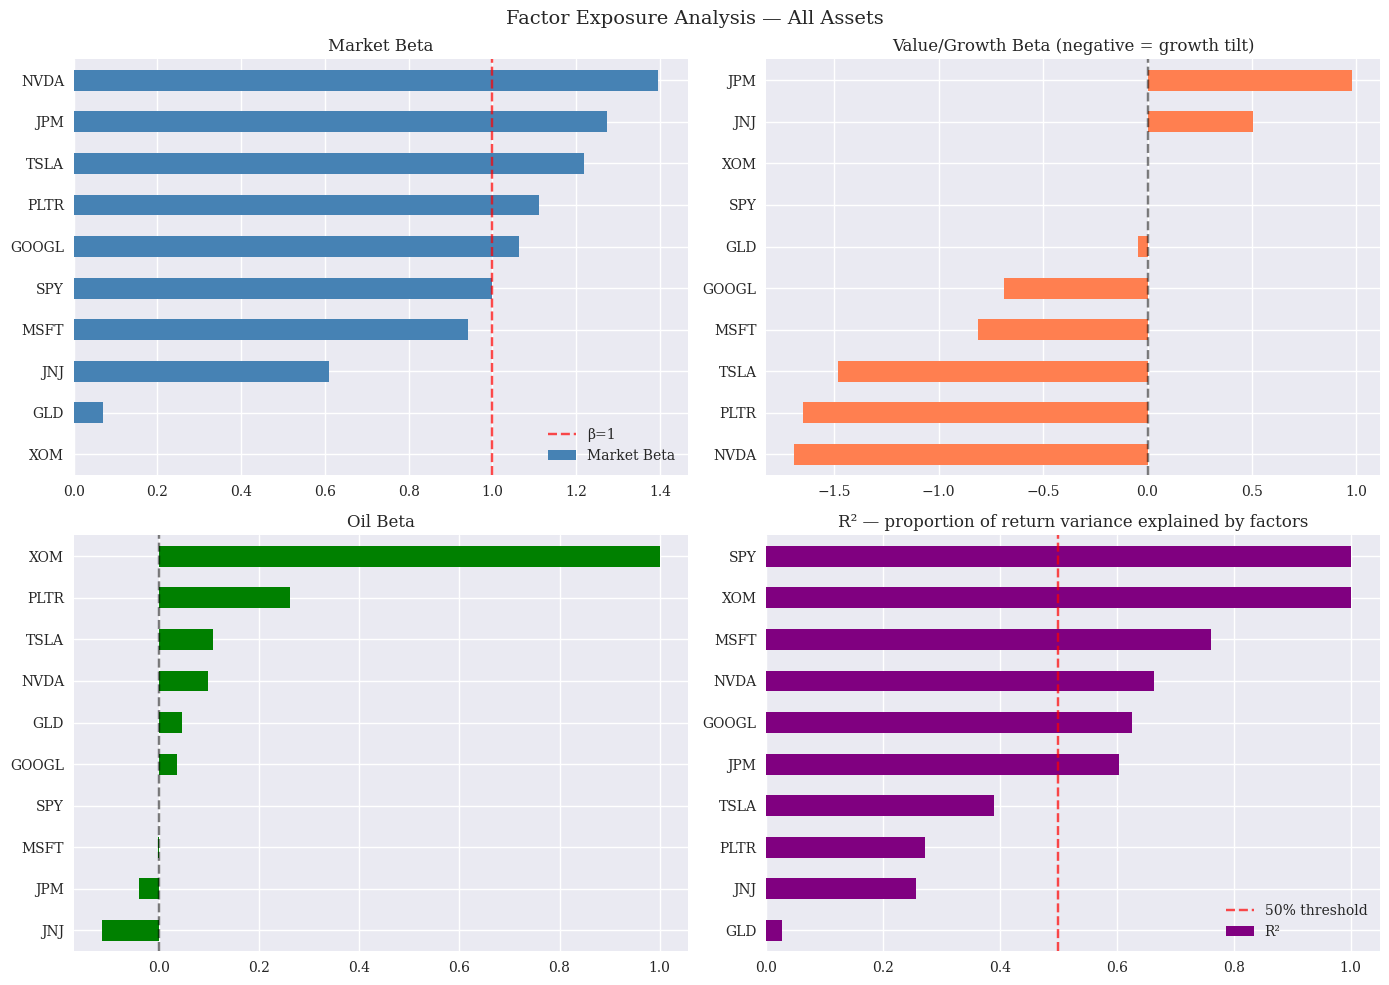

Chart saved as block2_factor_exposures.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Factor Exposure Analysis — All Assets', fontsize=14)

# Market beta
factor_exposures['Market Beta'].sort_values().plot(
    kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Market Beta')
axes[0,0].axvline(x=1, color='red', linestyle='--', alpha=0.7, label='β=1')
axes[0,0].legend()

# Value/Growth beta
factor_exposures['Value/Growth Beta'].sort_values().plot(
    kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Value/Growth Beta (negative = growth tilt)')
axes[0,1].axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Oil beta
factor_exposures['Oil Beta'].sort_values().plot(
    kind='barh', ax=axes[1,0], color='green')
axes[1,0].set_title('Oil Beta')
axes[1,0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

# R-squared
factor_exposures['R²'].sort_values().plot(
    kind='barh', ax=axes[1,1], color='purple')
axes[1,1].set_title('R² — proportion of return variance explained by factors')
axes[1,1].axvline(x=0.5, color='red', linestyle='--',
                   alpha=0.7, label='50% threshold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('block2_factor_exposures.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as block2_factor_exposures.png")

## Findings & Interpretation

**Market beta.** NVDA carries the highest market beta (1.40) — the most systematically volatile name in the universe. JNJ is the genuinely defensive equity at 0.61, reflecting stable healthcare demand across economic cycles. XOM's near-zero market beta (≈0.00) is not defensiveness — it is a consequence of factor construction: XOM's systematic variation is almost entirely absorbed by the oil factor rather than the market factor, since XOM's oil beta ≈ 1.00 by construction.

**Style exposure.** JPM (+0.98) and JNJ (+0.51) load positively on the value/growth spread, confirming value character. NVDA (−1.69), PLTR (−1.65), and TSLA (−1.48) load strongly negative, confirming growth character — consistent with their market positioning.

**Alpha.** NVDA generated 21.46% annualised alpha — genuine outperformance beyond what market, style, and oil exposure predict. PLTR generated −3.14% alpha — consistent underperformance despite its AI narrative, once its factor exposures are accounted for.

**Explanatory power (R²).** Excluding SPY and XOM (R² ≈ 1 by construction), NVDA shows the most attractive combination in the portfolio: 66.3% of its return variation is explained by the three factors, yet it still delivers 21.46% of return the factors cannot account for. A well-explained stock that still generates strong alpha is a stronger signal than a poorly-explained stock with the same alpha, since the latter could simply be missing a fourth factor. GLD sits at the opposite extreme, with R² of 0.027 — it operates in an almost entirely separate return universe from the other nine assets, which is precisely why it plays an outsized diversification role in Block 3.

These findings directly informed the optimiser's weight decisions in Block 3.

## Block 3 — Portfolio Optimisation (Modern Portfolio Theory)

### Objective
Find the mathematically optimal allocation across the ten assets using Modern Portfolio Theory — maximising return per unit of risk subject to real-world constraints.

### Portfolios Constructed
- **Maximum Sharpe ratio portfolio:** the allocation with the best risk-adjusted return
- **Minimum variance portfolio:** the allocation with the lowest achievable volatility, irrespective of return
- **Efficient frontier:** a curve of optimal portfolios connecting the two, tracing the best attainable return at every level of risk

### Key Metric — Sharpe Ratio
Sharpe = (Portfolio Return − Risk-Free Rate) / Portfolio Volatility — the excess return earned per unit of risk taken. A Sharpe ratio of 1.38, for example, means each 1% of volatility accepted was compensated with 1.38% of excess return; it is a ratio, not a percentage premium on capital.

### Key Insight — Why Diversification Works Mathematically
Portfolio volatility is not a weighted average of individual asset volatilities. It is determined by the full covariance matrix — σ_p = √(wᵀΣw). When assets have low covariance, the portfolio volatility comes out lower than any simple average would predict — this is the mathematical basis of diversification, not just an intuition.

In [15]:
# --- Core portfolio functions ---
# These are called hundreds of times by the optimiser internally
# Every call goes back to the mean returns and covariance matrix from Block 1

# --- Core portfolio functions ---
# These are called hundreds of times by the optimiser internally
# Every call goes back to the mean returns and covariance matrix from Block 1

# Compute covariance matrix once explicitly
# Using rets_aligned to ensure consistency with factor model dates
cov_matrix = rets_aligned.cov() * 252
cov_matrix = cov_matrix.loc[tickers, tickers] # reordering covariance matrix to match tickers list


mean_returns = rets_aligned.mean() * 252
mean_returns = mean_returns.loc[tickers] # reordering mean returns to match tickers list

def port_ret(weights):
    """Annualised portfolio return."""
    return np.sum(mean_returns * weights)  # uses reordered mean_returns

def port_vol(weights):
    """Annualised portfolio volatility."""
    return np.sqrt(np.dot(weights.T,
                          np.dot(cov_matrix, weights)))  # uses reordered cov_matrix

def sharpe_ratio(weights, rf=0.0):
    """Sharpe ratio."""
    return (port_ret(weights) - rf) / port_vol(weights)

# Verify equal weights
equal_weights = np.array([1/len(tickers)] * len(tickers))
print(f"Equal weight portfolio:")
print(f"  Return:     {port_ret(equal_weights)*100:.2f}%")
print(f"  Volatility: {port_vol(equal_weights)*100:.2f}%")
print(f"  Sharpe:     {sharpe_ratio(equal_weights):.3f}")

Equal weight portfolio:
  Return:     19.13%
  Volatility: 22.61%
  Sharpe:     0.846


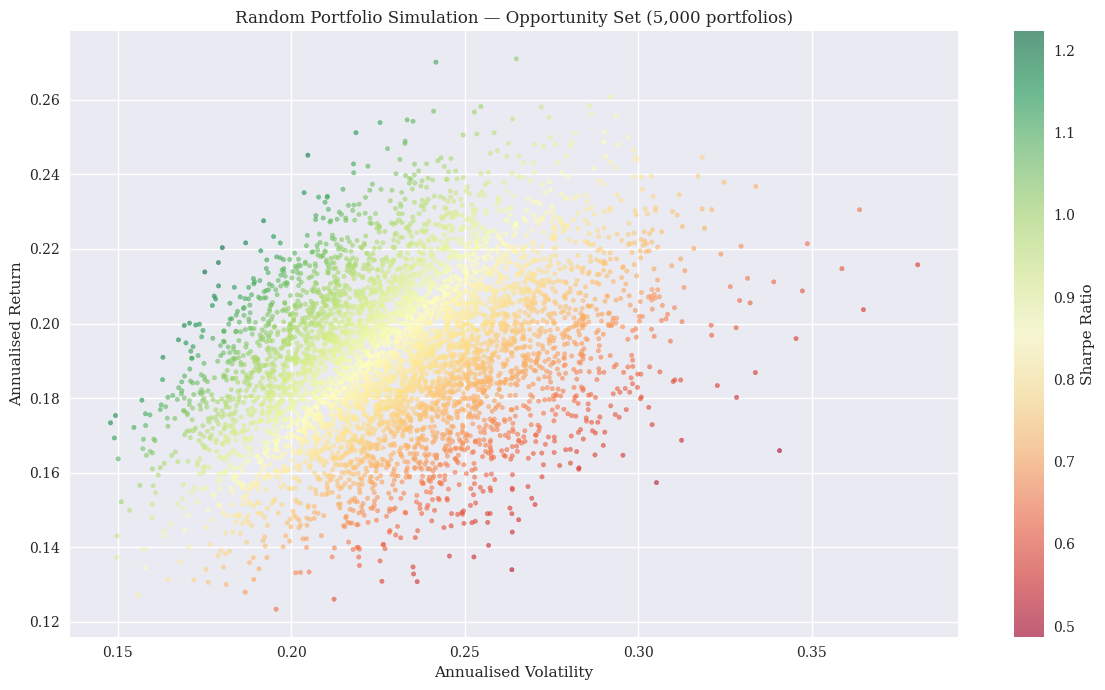

Return range:     12.3% to 27.1%
Volatility range: 14.8% to 38.1%
Sharpe range:     0.49 to 1.22


In [16]:
# --- Simulate 5000 random portfolios ---
# Purpose: visualise the full opportunity set before optimising
# Shows the shape of the achievable risk-return space
# The left edge of the cloud = efficient frontier

np.random.seed(42)
n_portfolios = 5000

port_returns = []
port_volatilities = []
port_sharpes = []
port_weights_list = []

for _ in range(n_portfolios):
    # Random weights — uniformly distributed, normalised to sum to 1
    w = np.random.random(len(tickers))
    w /= np.sum(w)

    ret = port_ret(w)
    vol = port_vol(w)

    port_returns.append(ret)
    port_volatilities.append(vol)
    port_sharpes.append(ret / vol)
    port_weights_list.append(w)

port_returns = np.array(port_returns)
port_volatilities = np.array(port_volatilities)
port_sharpes = np.array(port_sharpes)

# Plot the opportunity set
plt.figure(figsize=(12, 7))
scatter = plt.scatter(port_volatilities, port_returns,
                      c=port_sharpes, cmap='RdYlGn',
                      alpha=0.6, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Return')
plt.title('Random Portfolio Simulation — Opportunity Set (5,000 portfolios)')
plt.tight_layout()
plt.savefig('block3_opportunity_set.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Return range:     {port_returns.min()*100:.1f}% to {port_returns.max()*100:.1f}%")
print(f"Volatility range: {port_volatilities.min()*100:.1f}% to {port_volatilities.max()*100:.1f}%")
print(f"Sharpe range:     {port_sharpes.min():.2f} to {port_sharpes.max():.2f}")

In [17]:
# --- Maximum Sharpe Ratio Portfolio ---
# Objective: maximise Sharpe ratio = maximise return per unit of risk
# Sign flip: scipy minimises, so we minimise negative Sharpe ratio
# Same trick as Chapter 11 investor utility problem
import scipy.optimize as sco

def neg_sharpe(weights):
    """Negative Sharpe ratio — minimising this maximises Sharpe."""
    return -sharpe_ratio(weights)

# Constraints and bounds — same structure as Chapter 11
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(len(tickers)))
init_weights = equal_weights.copy()

# Run optimisation
opt_sharpe = sco.minimize(neg_sharpe,
                          init_weights,
                          method='SLSQP',
                          bounds=bounds,
                          constraints=constraints)

# Extract results
max_sharpe_weights = opt_sharpe['x']
max_sharpe_ret = port_ret(max_sharpe_weights)
max_sharpe_vol = port_vol(max_sharpe_weights)
max_sharpe_sr  = sharpe_ratio(max_sharpe_weights)

print("Maximum Sharpe Ratio Portfolio")
print("=" * 45)
print(f"Expected Return:  {max_sharpe_ret*100:.2f}%")
print(f"Volatility:       {max_sharpe_vol*100:.2f}%")
print(f"Sharpe Ratio:     {max_sharpe_sr:.3f}")
print(f"\nOptimisation successful: {opt_sharpe['success']}")
print(f"\nPortfolio Weights:")
weights_df = pd.DataFrame({
    'Ticker': tickers,
    'Weight': max_sharpe_weights
}).set_index('Ticker')
weights_df['Weight %'] = (weights_df['Weight'] * 100).round(2)
print(weights_df.sort_values('Weight', ascending=False))

Maximum Sharpe Ratio Portfolio
Expected Return:  34.17%
Volatility:       24.73%
Sharpe Ratio:     1.382

Optimisation successful: True

Portfolio Weights:
              Weight  Weight %
Ticker                        
XOM     6.027360e-01     60.27
NVDA    1.777178e-01     17.77
MSFT    1.361411e-01     13.61
JPM     8.340518e-02      8.34
PLTR    1.040292e-16      0.00
SPY     9.958397e-17      0.00
JNJ     6.391372e-17      0.00
GLD     6.722053e-18      0.00
TSLA    0.000000e+00      0.00
GOOGL   0.000000e+00      0.00


In [18]:
# Standalone Sharpe ratio for each asset
print("Standalone Sharpe ratios:")
for i, ticker in enumerate(tickers):
    ret = mean_returns.iloc[i]
    vol = np.sqrt(cov_matrix.iloc[i, i])
    sr = ret / vol
    print(f"  {ticker:6s}: return {ret*100:.1f}%  vol {vol*100:.1f}%  Sharpe {sr:.3f}")

Standalone Sharpe ratios:
  NVDA  : return 40.1%  vol 51.4%  Sharpe 0.780
  TSLA  : return 17.0%  vol 58.8%  Sharpe 0.290
  PLTR  : return 18.3%  vol 72.6%  Sharpe 0.252
  GOOGL : return 19.9%  vol 31.5%  Sharpe 0.633
  MSFT  : return 18.8%  vol 27.7%  Sharpe 0.680
  JPM   : return 20.5%  vol 25.6%  Sharpe 0.801
  JNJ   : return 4.3%  vol 16.3%  Sharpe 0.262
  XOM   : return 37.8%  vol 31.9%  Sharpe 1.186
  SPY   : return 12.3%  vol 17.5%  Sharpe 0.703
  GLD   : return 2.4%  vol 14.3%  Sharpe 0.165


In [19]:
# --- Minimum Variance Portfolio ---
# Objective: minimise portfolio volatility regardless of return
# No sign flip needed — we are directly minimising volatility
# Same constraints and bounds as maximum Sharpe

opt_var = sco.minimize(port_vol,
                       init_weights,
                       method='SLSQP',
                       bounds=bounds,
                       constraints=constraints)

min_var_weights = opt_var['x']
min_var_ret = port_ret(min_var_weights)
min_var_vol = port_vol(min_var_weights)
min_var_sr  = sharpe_ratio(min_var_weights)

print("Minimum Variance Portfolio")
print("=" * 45)
print(f"Expected Return:  {min_var_ret*100:.2f}%")
print(f"Volatility:       {min_var_vol*100:.2f}%")
print(f"Sharpe Ratio:     {min_var_sr:.3f}")
print(f"\nOptimisation successful: {opt_var['success']}")
print(f"\nPortfolio Weights:")
min_var_df = pd.DataFrame({
    'Ticker': tickers,
    'Weight': min_var_weights
}).set_index('Ticker')
min_var_df['Weight %'] = (min_var_df['Weight'] * 100).round(2)
print(min_var_df.sort_values('Weight', ascending=False))

Minimum Variance Portfolio
Expected Return:  5.70%
Volatility:       10.47%
Sharpe Ratio:     0.544

Optimisation successful: True

Portfolio Weights:
              Weight  Weight %
Ticker                        
GLD     4.937145e-01     49.37
JNJ     3.016871e-01     30.17
SPY     1.317811e-01     13.18
JPM     6.528860e-02      6.53
XOM     7.528700e-03      0.75
MSFT    7.341714e-18      0.00
NVDA    0.000000e+00      0.00
TSLA    0.000000e+00      0.00
PLTR    0.000000e+00      0.00
GOOGL   0.000000e+00      0.00


In [20]:
# --- Efficient Frontier ---
# For each target return level, find the minimum volatility portfolio
# Repeat across 50 target return levels
# The resulting curve is the efficient frontier

target_returns = np.linspace(
    min_var_ret + 0.001,    # start just above minimum variance return
    port_returns.max(),      # end at maximum achievable return
    50
)

efficient_volatilities = []
efficient_weights = []

for target in target_returns:
    cons = (
        {'type': 'eq', 'fun': lambda x: port_ret(x) - target},
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    )
    result = sco.minimize(port_vol,
                          init_weights,
                          method='SLSQP',
                          bounds=bounds,
                          constraints=cons)
    if result['success']:
        efficient_volatilities.append(result['fun'])
        efficient_weights.append(result['x'])
    else:
        efficient_volatilities.append(np.nan)
        efficient_weights.append(None)

efficient_volatilities = np.array(efficient_volatilities)

print(f"Efficient frontier computed: {np.sum(~np.isnan(efficient_volatilities))}/50 points successful")

Efficient frontier computed: 50/50 points successful


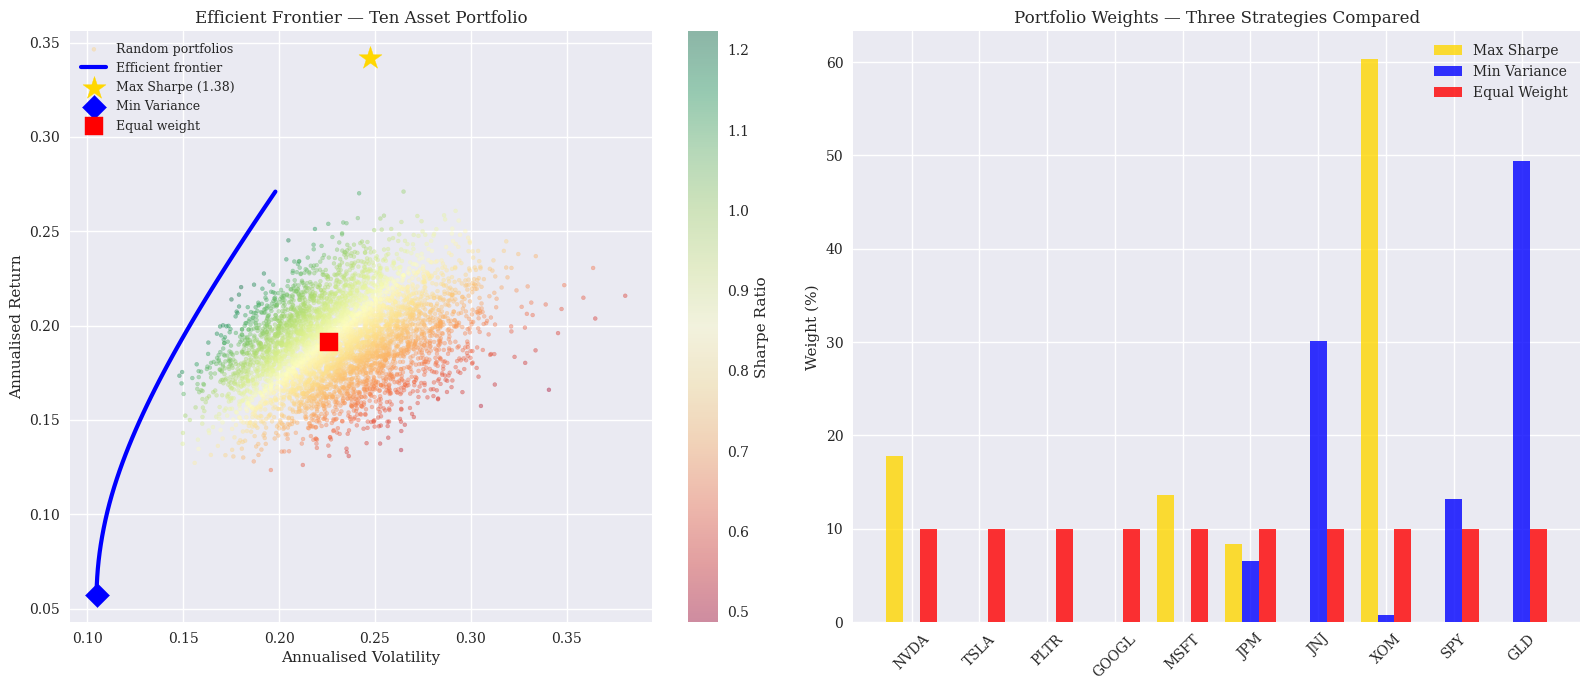


Portfolio Comparison Summary
Strategy               Return   Volatility   Sharpe
-------------------------------------------------------
Equal Weight           19.13%       22.61%    0.846
Max Sharpe             34.17%       24.73%    1.382
Min Variance            5.70%       10.47%    0.544


In [21]:
# --- Complete portfolio optimisation visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left plot: Efficient frontier with optimal portfolios ---
ax1 = axes[0]
scatter = ax1.scatter(port_volatilities, port_returns,
                      c=port_sharpes, cmap='RdYlGn',
                      alpha=0.4, s=8, label='Random portfolios')

# Efficient frontier
valid = ~np.isnan(efficient_volatilities)
ax1.plot(efficient_volatilities[valid], target_returns[valid],
         'b-', lw=3, label='Efficient frontier', zorder=5)

# Maximum Sharpe portfolio
ax1.scatter(max_sharpe_vol, max_sharpe_ret,
            marker='*', s=300, c='gold', zorder=10,
            label=f'Max Sharpe ({max_sharpe_sr:.2f})')

# Minimum variance portfolio
ax1.scatter(min_var_vol, min_var_ret,
            marker='D', s=150, c='blue', zorder=10,
            label=f'Min Variance')

# Equal weight portfolio
ax1.scatter(port_vol(equal_weights), port_ret(equal_weights),
            marker='s', s=150, c='red', zorder=10,
            label='Equal weight')

ax1.set_xlabel('Annualised Volatility')
ax1.set_ylabel('Annualised Return')
ax1.set_title('Efficient Frontier — Ten Asset Portfolio')
ax1.legend(loc='upper left', fontsize=9)
plt.colorbar(scatter, ax=ax1, label='Sharpe Ratio')

# --- Right plot: Portfolio weights comparison ---
ax2 = axes[1]
x = np.arange(len(tickers))
width = 0.25

ax2.bar(x - width, max_sharpe_weights * 100,
        width, label='Max Sharpe', color='gold', alpha=0.8)
ax2.bar(x, min_var_weights * 100,
        width, label='Min Variance', color='blue', alpha=0.8)
ax2.bar(x + width, equal_weights * 100,
        width, label='Equal Weight', color='red', alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(tickers, rotation=45)
ax2.set_ylabel('Weight (%)')
ax2.set_title('Portfolio Weights — Three Strategies Compared')
ax2.legend()

plt.tight_layout()
plt.savefig('block3_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary comparison table
print("\nPortfolio Comparison Summary")
print("=" * 55)
print(f"{'Strategy':<20} {'Return':>8} {'Volatility':>12} {'Sharpe':>8}")
print("-" * 55)
print(f"{'Equal Weight':<20} {port_ret(equal_weights)*100:>7.2f}% {port_vol(equal_weights)*100:>11.2f}% {sharpe_ratio(equal_weights):>8.3f}")
print(f"{'Max Sharpe':<20} {max_sharpe_ret*100:>7.2f}% {max_sharpe_vol*100:>11.2f}% {max_sharpe_sr:>8.3f}")
print(f"{'Min Variance':<20} {min_var_ret*100:>7.2f}% {min_var_vol*100:>11.2f}% {min_var_sr:>8.3f}")

## Findings & Interpretation

| Portfolio | Return | Volatility | Sharpe |
|---|---|---|---|
| Maximum Sharpe | 34.17% | 24.73% | 1.382 |
| Minimum Variance | 5.70% | 10.47% | 0.544 |

**The efficient frontier bends noticeably leftward.** A straight line connecting the minimum variance and maximum return portfolios would represent a world with no diversification benefit, where every blend simply averages the volatility of its components. The pronounced leftward bow reflects genuinely low covariance between assets in this universe — GLD and JNJ in particular sit almost orthogonal to the technology cluster in return space, and combining them produces real risk cancellation rather than a simple average.

**The maximum Sharpe portfolio concentrates in XOM (60.3%) and NVDA (17.8%)** rather than spreading broadly. XOM has the highest standalone Sharpe ratio in the universe, driven by its 2021–2022 historical return; NVDA contributes genuine alpha (21.46%, per Block 2) beyond its factor exposures. Critically, energy and technology are driven by different economic forces, so combining the two reduces portfolio volatility while preserving return — spreading further into correlated names like TSLA, PLTR, and GOOGL would add volatility without adding independent return. Standalone Sharpe ratio alone does not fully explain relative weights: JPM has a higher standalone Sharpe than MSFT, yet receives a smaller allocation (8.3% vs 13.6%), because MSFT's lower covariance with XOM — the dominant holding — gives it a higher marginal contribution to portfolio efficiency.

**The minimum variance portfolio holds almost nothing but GLD (49.4%), JNJ (30.2%), and SPY (13.2%).** These three combine the lowest standalone volatilities in the universe with low mutual covariance — gold, defensive healthcare, and the broad market are driven by different factors and move largely independently. The result is a portfolio volatility of 10.47%, lower than any single asset could achieve alone. High-volatility growth names receive zero weight because both their standalone variance and their covariance with existing holdings increase portfolio risk beyond the achievable minimum.

**Important limitation.** Both optimisations use full-period historical mean returns as forward-looking estimates. XOM's dominant weight in the maximum Sharpe portfolio is a direct product of the 2021–2022 energy supercycle — a historical regime with no guarantee of repeating. Backward-looking optimisation of this kind is a known weakness of static Modern Portfolio Theory, and is addressed directly in Block 6.

## Block 4 — Monte Carlo Simulation

### Objective
Transform the single-point expected return estimate from Block 3 into a full distribution of possible future outcomes using Geometric Brownian Motion (GBM) simulation.

### Method
10,000 independent price paths are simulated over 252 trading days for both the maximum Sharpe and minimum variance portfolios, using each portfolio's expected return and volatility from Block 3. Each path applies a different sequence of random daily return shocks, compounded forward through the full year. A starting value of 100 is used purely as a normalised base — final values read directly as percentage changes.

In [22]:
# BLOCK 4 IMPLEMENTATION
import scipy.stats as scs

# --- Simulation parameters ---
# Using maximum Sharpe portfolio as primary simulation target
# Will also run for minimum variance portfolio for comparison

# Portfolio parameters from Block 3
max_sharpe_ret = port_ret(max_sharpe_weights)
max_sharpe_vol = port_vol(max_sharpe_weights)
min_var_ret    = port_ret(min_var_weights)
min_var_vol    = port_vol(min_var_weights)

print("Portfolio parameters entering simulation:")
print(f"\nMaximum Sharpe Portfolio:")
print(f"  Expected annual return:     {max_sharpe_ret*100:.2f}%")
print(f"  Expected annual volatility: {max_sharpe_vol*100:.2f}%")
print(f"\nMinimum Variance Portfolio:")
print(f"  Expected annual return:     {min_var_ret*100:.2f}%")
print(f"  Expected annual volatility: {min_var_vol*100:.2f}%")

# Simulation settings
S0    = 100        # starting portfolio value (normalised to 100)
T     = 1.0        # time horizon — 1 year
M     = 252        # trading days
I     = 10000      # number of simulation paths
dt    = T / M      # daily time step

np.random.seed(42)
print(f"\nSimulation settings:")
print(f"  Starting value:   {S0}")
print(f"  Time horizon:     {T} year ({M} trading days)")
print(f"  Simulation paths: {I:,}")
print(f"  Daily time step:  {dt:.4f}")

Portfolio parameters entering simulation:

Maximum Sharpe Portfolio:
  Expected annual return:     34.17%
  Expected annual volatility: 24.73%

Minimum Variance Portfolio:
  Expected annual return:     5.70%
  Expected annual volatility: 10.47%

Simulation settings:
  Starting value:   100
  Time horizon:     1.0 year (252 trading days)
  Simulation paths: 10,000
  Daily time step:  0.0040


In [23]:
# GBM simulation function

def simulate_gbm(mu, sigma, S0, T, M, I, seed=42):
    np.random.seed(seed)
    dt = T / M

    # Generate random draws
    rand = np.random.standard_normal((M, I))

    # Moment matching across entire matrix
    # Subtract mean and divide by std across ALL draws
    rand = (rand - rand.mean()) / rand.std()

    # Initialise path matrix
    S = np.zeros((M + 1, I))
    S[0] = S0

    # Simulate forward
    for t in range(1, M + 1):
        S[t] = S[t-1] * np.exp(
            (mu - 0.5 * sigma**2) * dt +
            sigma * np.sqrt(dt) * rand[t-1]
        )

    return S

# Rerun both simulations
S_max_sharpe = simulate_gbm(
    mu=max_sharpe_ret,
    sigma=max_sharpe_vol,
    S0=S0, T=T, M=M, I=I
)

S_min_var = simulate_gbm(
    mu=min_var_ret,
    sigma=min_var_vol,
    S0=S0, T=T, M=M, I=I
)

# Quick sanity check before running full summary
print("Sanity check:")
print(f"Max Sharpe — first 5 final values: {S_max_sharpe[-1][:5].round(2)}")
print(f"Max Sharpe — std of final values:  {S_max_sharpe[-1].std():.4f}")
print(f"Min Var    — first 5 final values: {S_min_var[-1][:5].round(2)}")
print(f"Min Var    — std of final values:  {S_min_var[-1].std():.4f}")

Sanity check:
Max Sharpe — first 5 final values: [209.55 172.07 134.94 141.27 158.32]
Max Sharpe — std of final values:  35.1078
Min Var    — first 5 final values: [126.25 116.14 104.77 106.83 112.11]
Min Var    — std of final values:  11.0758


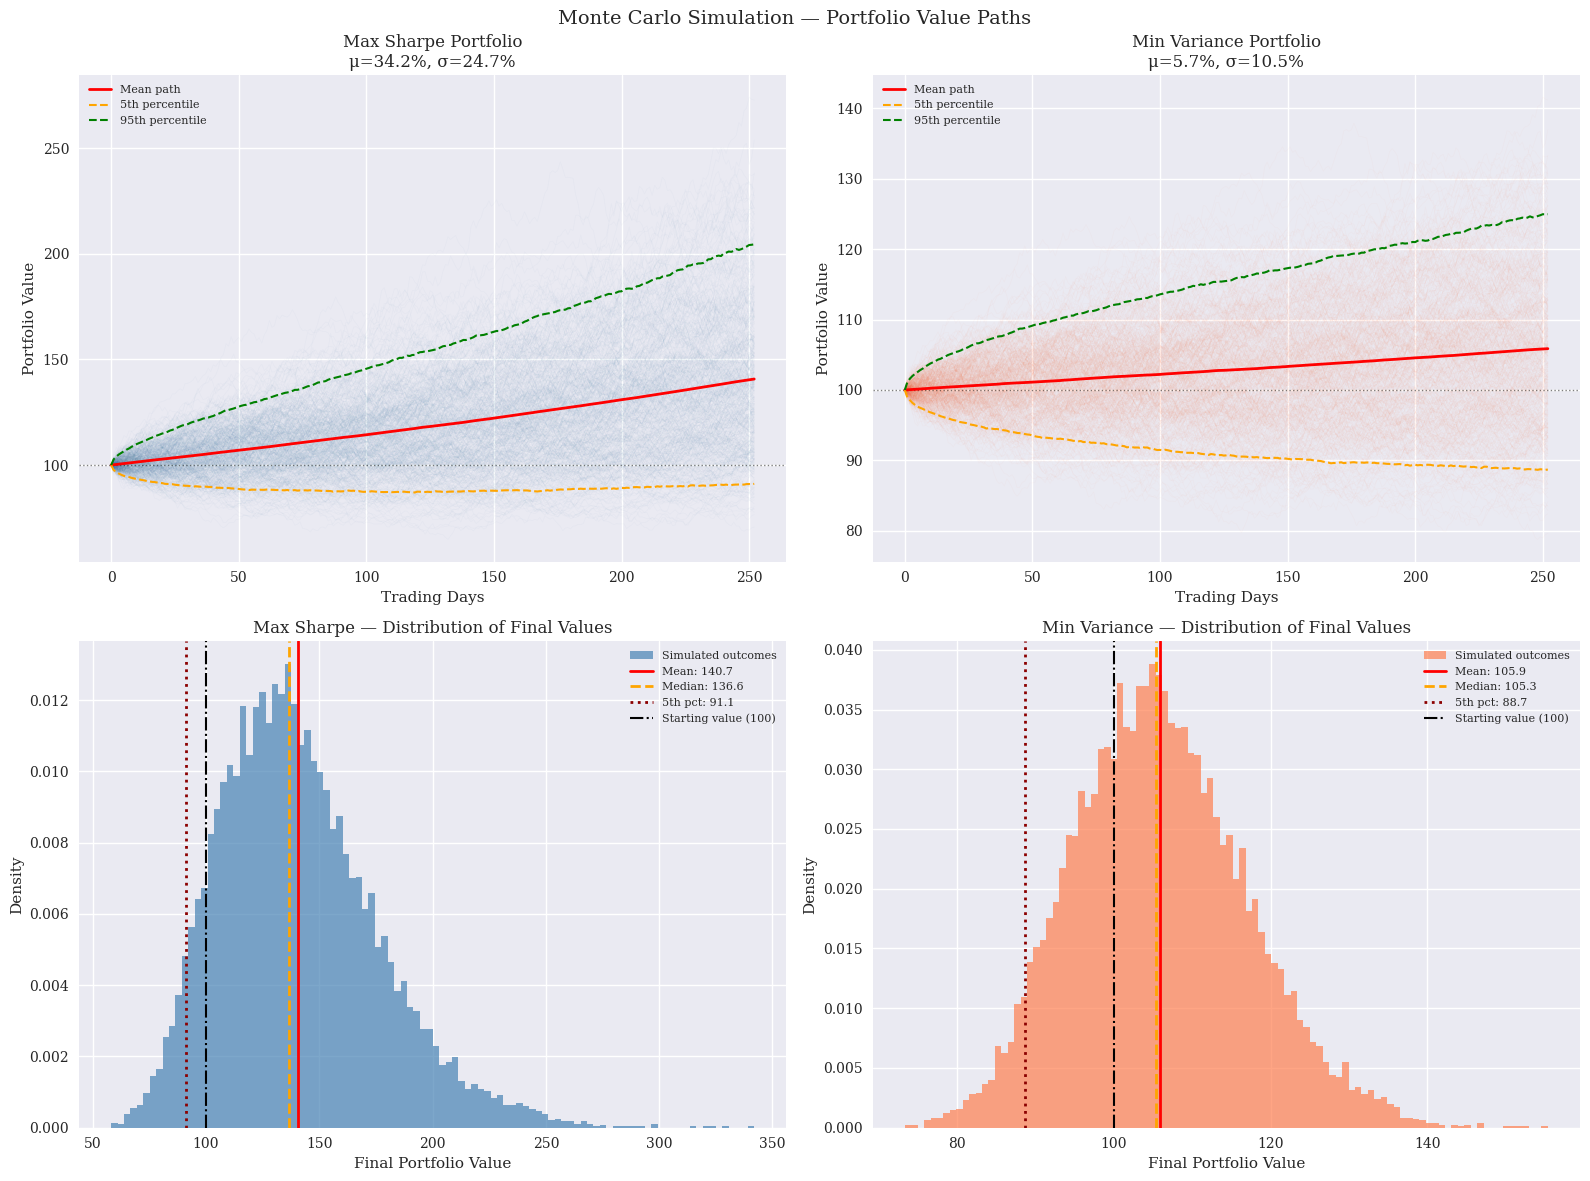

In [24]:
# Path visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Monte Carlo Simulation — Portfolio Value Paths', fontsize=14)

# --- Top left: Maximum Sharpe paths ---
ax1 = axes[0, 0]
# Plot subset of paths for clarity — all 10,000 would be unreadable
ax1.plot(S_max_sharpe[:, :500], alpha=0.03, color='steelblue', lw=0.5)
ax1.plot(np.mean(S_max_sharpe, axis=1), color='red', lw=2,
         label=f'Mean path', zorder=5)
ax1.plot(np.percentile(S_max_sharpe, 5, axis=1), color='orange',
         lw=1.5, linestyle='--', label='5th percentile', zorder=5)
ax1.plot(np.percentile(S_max_sharpe, 95, axis=1), color='green',
         lw=1.5, linestyle='--', label='95th percentile', zorder=5)
ax1.axhline(y=S0, color='black', linestyle=':', lw=1, alpha=0.5)
ax1.set_title(f'Max Sharpe Portfolio\nμ={max_sharpe_ret*100:.1f}%, σ={max_sharpe_vol*100:.1f}%')
ax1.set_xlabel('Trading Days')
ax1.set_ylabel('Portfolio Value')
ax1.legend(fontsize=8)

# --- Top right: Minimum Variance paths ---
ax2 = axes[0, 1]
ax2.plot(S_min_var[:, :500], alpha=0.03, color='coral', lw=0.5)
ax2.plot(np.mean(S_min_var, axis=1), color='red', lw=2,
         label='Mean path', zorder=5)
ax2.plot(np.percentile(S_min_var, 5, axis=1), color='orange',
         lw=1.5, linestyle='--', label='5th percentile', zorder=5)
ax2.plot(np.percentile(S_min_var, 95, axis=1), color='green',
         lw=1.5, linestyle='--', label='95th percentile', zorder=5)
ax2.axhline(y=S0, color='black', linestyle=':', lw=1, alpha=0.5)
ax2.set_title(f'Min Variance Portfolio\nμ={min_var_ret*100:.1f}%, σ={min_var_vol*100:.1f}%')
ax2.set_xlabel('Trading Days')
ax2.set_ylabel('Portfolio Value')
ax2.legend(fontsize=8)

# --- Bottom left: Final value distribution — Max Sharpe ---
ax3 = axes[1, 0]
ax3.hist(S_max_sharpe[-1], bins=100, density=True,
         color='steelblue', alpha=0.7, label='Simulated outcomes')
ax3.axvline(x=S_max_sharpe[-1].mean(), color='red', lw=2,
            label=f'Mean: {S_max_sharpe[-1].mean():.1f}')
ax3.axvline(x=np.median(S_max_sharpe[-1]), color='orange', lw=2,
            linestyle='--', label=f'Median: {np.median(S_max_sharpe[-1]):.1f}')
ax3.axvline(x=np.percentile(S_max_sharpe[-1], 5), color='darkred',
            lw=2, linestyle=':', label=f'5th pct: {np.percentile(S_max_sharpe[-1], 5):.1f}')
ax3.axvline(x=S0, color='black', lw=1.5, linestyle='-.',
            label='Starting value (100)')
ax3.set_title('Max Sharpe — Distribution of Final Values')
ax3.set_xlabel('Final Portfolio Value')
ax3.set_ylabel('Density')
ax3.legend(fontsize=8)

# --- Bottom right: Final value distribution — Min Variance ---
ax4 = axes[1, 1]
ax4.hist(S_min_var[-1], bins=100, density=True,
         color='coral', alpha=0.7, label='Simulated outcomes')
ax4.axvline(x=S_min_var[-1].mean(), color='red', lw=2,
            label=f'Mean: {S_min_var[-1].mean():.1f}')
ax4.axvline(x=np.median(S_min_var[-1]), color='orange', lw=2,
            linestyle='--', label=f'Median: {np.median(S_min_var[-1]):.1f}')
ax4.axvline(x=np.percentile(S_min_var[-1], 5), color='darkred',
            lw=2, linestyle=':', label=f'5th pct: {np.percentile(S_min_var[-1], 5):.1f}')
ax4.axvline(x=S0, color='black', lw=1.5, linestyle='-.',
            label='Starting value (100)')
ax4.set_title('Min Variance — Distribution of Final Values')
ax4.set_xlabel('Final Portfolio Value')
ax4.set_ylabel('Density')
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('block4_monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# summary statistics for both portfolios
def simulation_summary(S, portfolio_name, S0=100):
    """Print comprehensive summary statistics for a simulation."""
    final_values = S[-1]
    returns = (final_values - S0) / S0 * 100

    print(f"\n{'='*50}")
    print(f"{portfolio_name}")
    print(f"{'='*50}")
    print(f"Final portfolio value statistics (start = {S0}):")
    print(f"  Mean:              {final_values.mean():.2f}  ({returns.mean():.1f}% return)")
    print(f"  Median:            {np.median(final_values):.2f}  ({np.median(returns):.1f}% return)")
    print(f"  Std deviation:     {final_values.std():.2f}")
    print(f"  Best outcome:      {final_values.max():.2f}  ({returns.max():.1f}% return)")
    print(f"  Worst outcome:     {final_values.min():.2f}  ({returns.min():.1f}% return)")
    print(f"\nPercentile outcomes:")
    for pct in [1, 5, 10, 25, 75, 90, 95, 99]:
        val = np.percentile(final_values, pct)
        ret = (val - S0) / S0 * 100
        print(f"  {pct:3d}th percentile: {val:7.2f}  ({ret:+.1f}%)")
    print(f"\nProbability of loss (final value < {S0}): "
          f"{(final_values < S0).mean()*100:.1f}%")
    print(f"Probability of >20% gain:  "
          f"{(final_values > S0*1.2).mean()*100:.1f}%")
    print(f"Probability of >50% gain:  "
          f"{(final_values > S0*1.5).mean()*100:.1f}%")

simulation_summary(S_max_sharpe, "Maximum Sharpe Portfolio")
simulation_summary(S_min_var, "Minimum Variance Portfolio")


Maximum Sharpe Portfolio
Final portfolio value statistics (start = 100):
  Mean:              140.70  (40.7% return)
  Median:            136.64  (36.6% return)
  Std deviation:     35.11
  Best outcome:      341.94  (241.9% return)
  Worst outcome:     58.17  (-41.8% return)

Percentile outcomes:
    1th percentile:   76.52  (-23.5%)
    5th percentile:   91.09  (-8.9%)
   10th percentile:   99.25  (-0.8%)
   25th percentile:  115.59  (+15.6%)
   75th percentile:  161.29  (+61.3%)
   90th percentile:  187.37  (+87.4%)
   95th percentile:  204.47  (+104.5%)
   99th percentile:  240.60  (+140.6%)

Probability of loss (final value < 100): 10.5%
Probability of >20% gain:  70.0%
Probability of >50% gain:  35.1%

Minimum Variance Portfolio
Final portfolio value statistics (start = 100):
  Mean:              105.86  (5.9% return)
  Median:            105.33  (5.3% return)
  Std deviation:     11.08
  Best outcome:      155.35  (55.4% return)
  Worst outcome:     73.36  (-26.6% return)

Perc

## Findings & Interpretation

**Why uncertainty widens over time.** Each day's random shock is applied to the value produced by the previous day's shock, not to the original starting value — so 252 days of compounding produce a spread between best and worst paths far larger than any single day's volatility would suggest. This is compounding uncertainty, not increasing daily risk.

**Why the distribution is right-skewed.** GBM assumes daily log returns are normally distributed, but compounding 252 of them transforms the distribution of *final values* from normal into log-normal — positively skewed, with a hard floor at zero and a long right tail from paths that compound exceptionally well. The mean final value (140.70) exceeds the median (136.64) because that right tail pulls the average upward; more than half of simulated outcomes finish below the mean. The Itô correction term in the simulation corrects for this asymmetry, adjusting drift downward so the simulated mean aligns with the true expected return from Block 3 rather than overstating it.

**Probability of loss.** The maximum Sharpe portfolio showed a 10.5% probability of loss despite its 34.17% expected return. The minimum variance portfolio's probability of loss was higher, despite lower volatility — its 5.70% expected return provides too thin a cushion against its own 10.47% volatility, whereas the maximum Sharpe portfolio's much larger return cushion more than offsets its higher volatility. Expected return alone is therefore a misleading summary of what an investor is actually signing up for; the full distribution is required to answer the question properly.

**Limitation.** Block 1 proved that daily returns are not normally distributed for any of the ten assets. GBM's normality assumption means this simulation underrepresents extreme negative outcomes — actual worst-case scenarios are likely worse than the 1st percentile of simulated paths suggests. This gap is quantified directly in Block 5.

## Block 5 — Risk Measurement (Value at Risk)

### Objective
Extract specific downside risk thresholds from the Block 4 simulation and compare three distinct VaR methodologies to quantify the cost of the normality assumption identified in Block 1.

### Three VaR Approaches
- **Simulation VaR:** reads percentiles directly from the Block 4 GBM output — inherits GBM's normality assumption
- **Historical VaR:** computed from actual observed daily returns — makes no distribution assumption, so it captures real fat tails
- **Analytical VaR:** computed directly from the normal distribution formula — fastest to compute, and most exposed to the fat-tail problem

In [26]:
import scipy.stats as scs

# --- Simulation-based VaR ---
# Read directly from Block 4 simulation output
# No additional model assumptions beyond GBM

def simulation_var(S, S0=100, confidence_levels=[0.90, 0.95, 0.99]):
    """
    Compute VaR from simulation output at multiple confidence levels.
    S: simulation matrix from Block 4 (M+1, I)
    Returns VaR as positive loss percentages
    """
    final_values = S[-1]
    returns = (final_values - S0) / S0

    print("Simulation-based VaR:")
    print("-" * 40)
    for cl in confidence_levels:
        # VaR = negative of the (1-cl) percentile of returns
        # e.g. 95% VaR = negative of 5th percentile
        var = -np.percentile(returns, (1 - cl) * 100)
        print(f"  {cl*100:.0f}% confidence: {var*100:.2f}% loss")
    return returns

print("Maximum Sharpe Portfolio:")
ms_returns = simulation_var(S_max_sharpe)

print("\nMinimum Variance Portfolio:")
mv_returns = simulation_var(S_min_var)

Maximum Sharpe Portfolio:
Simulation-based VaR:
----------------------------------------
  90% confidence: 0.75% loss
  95% confidence: 8.91% loss
  99% confidence: 23.48% loss

Minimum Variance Portfolio:
Simulation-based VaR:
----------------------------------------
  90% confidence: 8.01% loss
  95% confidence: 11.29% loss
  99% confidence: 17.61% loss


In [27]:
# Create properly indexed weight series for each portfolio
max_sharpe_weights_series = pd.Series(
    max_sharpe_weights, index=tickers)

min_var_weights_series = pd.Series(
    min_var_weights, index=tickers)

# Verify alignment
print("Max Sharpe weights correctly indexed:")
print(max_sharpe_weights_series.round(4))
print("\nMin Variance weights correctly indexed:")
print(min_var_weights_series.round(4))

# Compute daily portfolio returns using indexed series
# pandas dot product aligns on index automatically
ms_daily = rets_aligned.dot(max_sharpe_weights_series)
mv_daily = rets_aligned.dot(min_var_weights_series)

# Verify
print("\nms_daily std (should be ~1.56% daily = ~24.7% annual):")
print(f"  {ms_daily.std()*100:.4f}%  (annualised: {ms_daily.std()*np.sqrt(252)*100:.2f}%)")
print("\nmv_daily std (should be ~0.66% daily = ~10.5% annual):")
print(f"  {mv_daily.std()*100:.4f}%  (annualised: {mv_daily.std()*np.sqrt(252)*100:.2f}%)")

Max Sharpe weights correctly indexed:
NVDA     0.1777
TSLA     0.0000
PLTR     0.0000
GOOGL    0.0000
MSFT     0.1361
JPM      0.0834
JNJ      0.0000
XOM      0.6027
SPY      0.0000
GLD      0.0000
dtype: float64

Min Variance weights correctly indexed:
NVDA     0.0000
TSLA     0.0000
PLTR     0.0000
GOOGL    0.0000
MSFT     0.0000
JPM      0.0653
JNJ      0.3017
XOM      0.0075
SPY      0.1318
GLD      0.4937
dtype: float64

ms_daily std (should be ~1.56% daily = ~24.7% annual):
  1.5576%  (annualised: 24.73%)

mv_daily std (should be ~0.66% daily = ~10.5% annual):
  0.6598%  (annualised: 10.47%)


In [28]:
# --- Historical VaR ---
# Uses actual observed daily returns — no model assumptions
# Applies portfolio weights to historical returns directly
def historical_var(portfolio_daily_returns, label,
                   confidence_levels=[0.90, 0.95, 0.99]):
    """
    Compute historical VaR from pre-computed daily portfolio returns.
    """
    print(f"Historical VaR — {label}:")
    print("-" * 40)
    for cl in confidence_levels:
        daily_var = -np.percentile(portfolio_daily_returns, (1-cl)*100)
        annual_var = daily_var * np.sqrt(252)
        print(f"  {cl*100:.0f}% confidence: {annual_var*100:.2f}% loss "
              f"(daily: {daily_var*100:.2f}%)")

historical_var(ms_daily, "Maximum Sharpe Portfolio")
historical_var(mv_daily, "Minimum Variance Portfolio")

Historical VaR — Maximum Sharpe Portfolio:
----------------------------------------
  90% confidence: 27.76% loss (daily: 1.75%)
  95% confidence: 39.05% loss (daily: 2.46%)
  99% confidence: 57.70% loss (daily: 3.63%)
Historical VaR — Minimum Variance Portfolio:
----------------------------------------
  90% confidence: 12.86% loss (daily: 0.81%)
  95% confidence: 17.17% loss (daily: 1.08%)
  99% confidence: 25.56% loss (daily: 1.61%)


In [29]:
# Check the worst daily returns for max sharpe portfolio
print("Maximum Sharpe — worst 10 daily returns:")
print(ms_daily.nsmallest(10) * 100)

print(f"\nms_daily 10th percentile: {np.percentile(ms_daily, 10)*100:.4f}%")
print(f"Annualised 90% historical VaR: {-np.percentile(ms_daily, 10)*np.sqrt(252)*100:.2f}%")

Maximum Sharpe — worst 10 daily returns:
Date
2022-05-09   -7.311841
2022-06-13   -5.120208
2020-10-28   -4.321828
2022-09-13   -4.258032
2022-11-09   -4.164554
2022-06-16   -3.806486
2021-03-18   -3.731979
2022-09-23   -3.690645
2022-04-11   -3.639110
2021-01-15   -3.610608
dtype: float64

ms_daily 10th percentile: -1.7486%
Annualised 90% historical VaR: 27.76%


In [30]:
# --- Analytical VaR ---
# Uses normal distribution formula directly
# Fastest to compute but most vulnerable to fat tail problem

def analytical_var(mu, sigma, confidence_levels=[0.90, 0.95, 0.99], T=1.0):
    """
    Compute VaR analytically using normal distribution assumption.
    mu:    annualised portfolio return
    sigma: annualised portfolio volatility
    T:     time horizon in years
    """
    print("Analytical VaR (normal distribution assumption):")
    print("-" * 40)
    for cl in confidence_levels:
        # z-score for this confidence level
        z = scs.norm.ppf(1 - cl)   # negative number — left tail
        # VaR formula: -(mu*T + z*sigma*sqrt(T))
        var = -(mu * T + z * sigma * np.sqrt(T))
        print(f"  {cl*100:.0f}% confidence: {var*100:.2f}% loss "
              f"(z-score: {z:.3f})")

print("Maximum Sharpe Portfolio:")
analytical_var(max_sharpe_ret, max_sharpe_vol)

print("\nMinimum Variance Portfolio:")
analytical_var(min_var_ret, min_var_vol)

Maximum Sharpe Portfolio:
Analytical VaR (normal distribution assumption):
----------------------------------------
  90% confidence: -2.48% loss (z-score: -1.282)
  95% confidence: 6.50% loss (z-score: -1.645)
  99% confidence: 23.35% loss (z-score: -2.326)

Minimum Variance Portfolio:
Analytical VaR (normal distribution assumption):
----------------------------------------
  90% confidence: 7.72% loss (z-score: -1.282)
  95% confidence: 11.53% loss (z-score: -1.645)
  99% confidence: 18.67% loss (z-score: -2.326)



VaR Comparison — Maximum Sharpe Portfolio
Confidence        Simulation   Historical   Analytical
-----------------------------------------------------------------
  90%                0.75%      27.76%      -2.48%
  95%                8.91%      39.05%       6.50%
  99%               23.48%      57.70%      23.35%

VaR Comparison — Minimum Variance Portfolio
Confidence        Simulation   Historical   Analytical
-----------------------------------------------------------------
  90%                8.01%      12.86%       7.72%
  95%               11.29%      17.17%      11.53%
  99%               17.61%      25.56%      18.67%


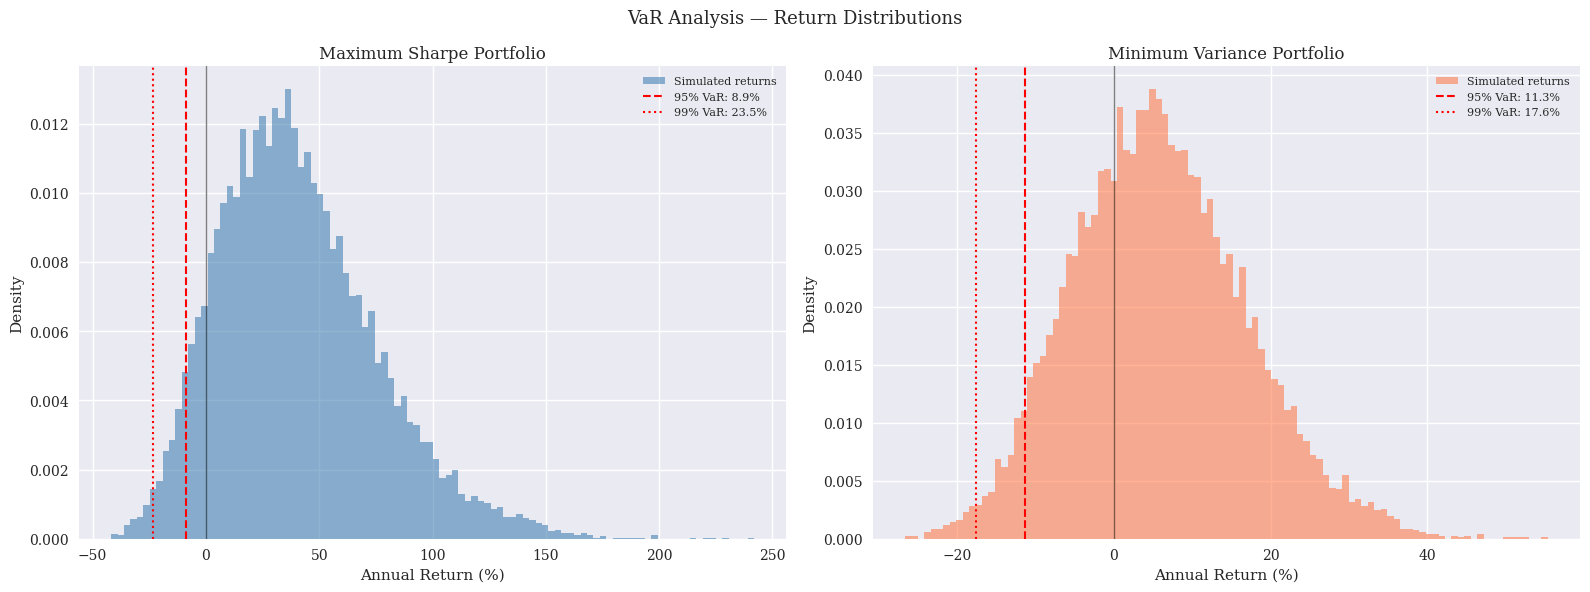

In [31]:
# --- Comparison table ---
confidence_levels = [0.90, 0.95, 0.99]

def compute_all_var(sim_returns, daily_returns, mu, sigma, label):
    print(f"\nVaR Comparison — {label}")
    print("=" * 65)
    print(f"{'Confidence':<15} {'Simulation':>12} {'Historical':>12} {'Analytical':>12}")
    print("-" * 65)

    for cl in confidence_levels:
        # Simulation VaR — percentile of annual simulated returns
        sim_var = -np.percentile(sim_returns, (1-cl)*100) * 100

        # Historical VaR — percentile of daily returns scaled to annual
        hist_daily_var = np.percentile(daily_returns, (1-cl)*100)
        hist_var = -hist_daily_var * np.sqrt(252) * 100

        # Analytical VaR — normal distribution formula
        z = scs.norm.ppf(1-cl)
        anal_var = -(mu + z * sigma) * 100

        print(f"  {cl*100:.0f}%"
              f"{'':9} {sim_var:>10.2f}%"
              f" {hist_var:>10.2f}%"
              f" {anal_var:>10.2f}%")

compute_all_var(ms_returns, ms_daily,
                max_sharpe_ret, max_sharpe_vol,
                "Maximum Sharpe Portfolio")

compute_all_var(mv_returns, mv_daily,
                min_var_ret, min_var_vol,
                "Minimum Variance Portfolio")

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('VaR Analysis — Return Distributions', fontsize=13)

for ax, returns, daily, mu, sigma, title, color in [
    (axes[0], ms_returns, ms_daily, max_sharpe_ret,
     max_sharpe_vol, 'Maximum Sharpe Portfolio', 'steelblue'),
    (axes[1], mv_returns, mv_daily, min_var_ret,
     min_var_vol, 'Minimum Variance Portfolio', 'coral')
]:
    ax.hist(returns * 100, bins=100, density=True,
            color=color, alpha=0.6, label='Simulated returns')

    # Mark VaR thresholds
    for cl, ls in [(0.95, '--'), (0.99, ':')]:
        var = -np.percentile(returns, (1-cl)*100) * 100
        ax.axvline(x=-var, color='red', linestyle=ls, lw=1.5,
                   label=f'{cl*100:.0f}% VaR: {var:.1f}%')

    ax.axvline(x=0, color='black', lw=1, alpha=0.5)
    ax.set_xlabel('Annual Return (%)')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('block5_var_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

2022 Stress Test Results:

Maximum Sharpe Portfolio in 2022:
  Starting value:  100.00
  Ending value:    77.52
  Total return:    -22.48%
  Maximum drawdown:-28.87%

Minimum Variance Portfolio in 2022:
  Starting value:  100.00
  Ending value:    76.46
  Total return:    -23.54%
  Maximum drawdown:-32.15%


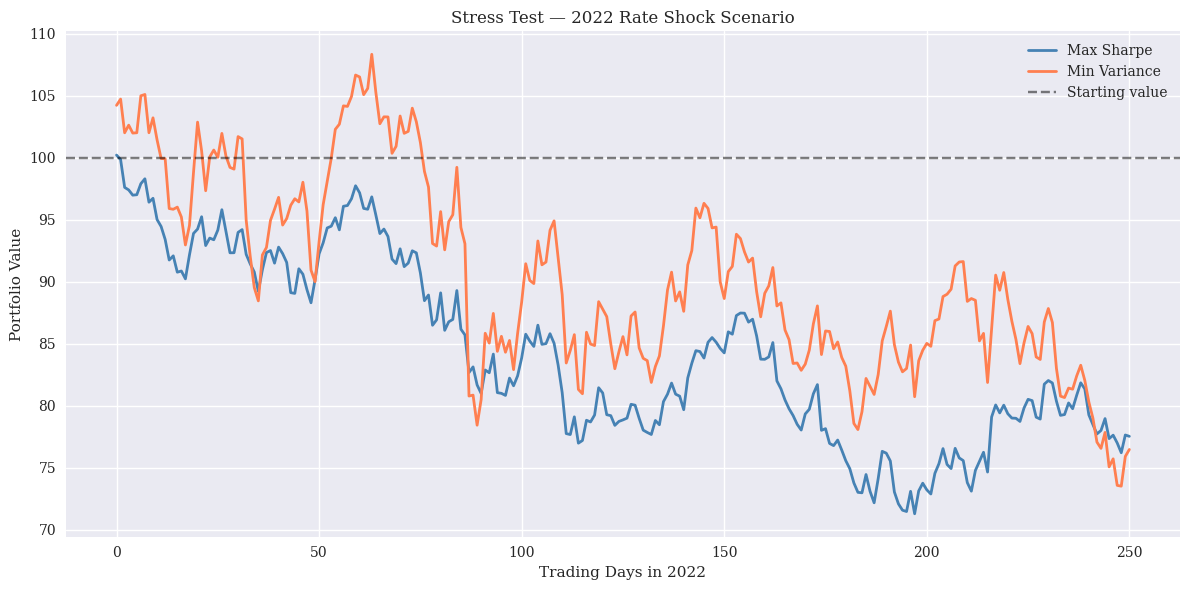

In [32]:
# --- Stress Test — 2022 Rate Shock ---
# Apply actual 2022 return sequence to optimal portfolio weights
# 2022 was characterised by aggressive Fed rate hikes
# hitting growth stocks particularly hard

# Extract 2022 returns from aligned return series
returns_2022 = rets_aligned[
    (rets_aligned.index >= '2022-01-01') &
    (rets_aligned.index <= '2022-12-31')
]

# Compute daily portfolio returns in 2022
ms_2022 = returns_2022.dot(max_sharpe_weights)
mv_2022 = returns_2022.dot(min_var_weights)

# Compound daily returns to get cumulative portfolio value through 2022
ms_2022_cumulative = (1 + ms_2022).cumprod() * 100
mv_2022_cumulative = (1 + mv_2022).cumprod() * 100

print("2022 Stress Test Results:")
print("=" * 50)
print(f"\nMaximum Sharpe Portfolio in 2022:")
print(f"  Starting value:  100.00")
print(f"  Ending value:    {ms_2022_cumulative.iloc[-1]:.2f}")
print(f"  Total return:    {(ms_2022_cumulative.iloc[-1]-100):.2f}%")
print(f"  Maximum drawdown:{(ms_2022_cumulative/ms_2022_cumulative.cummax()-1).min()*100:.2f}%")

print(f"\nMinimum Variance Portfolio in 2022:")
print(f"  Starting value:  100.00")
print(f"  Ending value:    {mv_2022_cumulative.iloc[-1]:.2f}")
print(f"  Total return:    {(mv_2022_cumulative.iloc[-1]-100):.2f}%")
print(f"  Maximum drawdown:{(mv_2022_cumulative/mv_2022_cumulative.cummax()-1).min()*100:.2f}%")

# Plot cumulative performance through 2022
plt.figure(figsize=(12, 6))
plt.plot(ms_2022_cumulative.values, label='Max Sharpe', color='steelblue', lw=2)
plt.plot(mv_2022_cumulative.values, label='Min Variance', color='coral', lw=2)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.5, label='Starting value')
plt.xlabel('Trading Days in 2022')
plt.ylabel('Portfolio Value')
plt.title('Stress Test — 2022 Rate Shock Scenario')
plt.legend()
plt.tight_layout()
plt.savefig('block5_stress_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings & Interpretation

**Historical VaR consistently and substantially exceeds both simulation and analytical VaR**, particularly at extreme confidence levels — direct evidence of the fat-tail problem identified in Block 1. At 99% confidence, the maximum Sharpe portfolio's historical VaR is 57.70%, more than double its analytical VaR of 23.35%. This gap is the normality assumption's cost, expressed in real terms: a −7.31% single-day loss occurred on 9 May 2022 (see the worst-daily-returns output above) — an observation that a normal-distribution model assigns near-zero probability to.

**A methodological nuance worth noting:** analytical VaR at the 90% confidence level comes out negative for the maximum Sharpe portfolio. This is not an error — it reflects that the portfolio's expected return is large enough, relative to its volatility, that a normal model assigns essentially zero probability of loss at that confidence level. The same is not true at 99% confidence, where the same return no longer fully offsets the tail risk.

**Stress test.** Applying the actual 2022 rate-shock return sequence to both portfolios shows the minimum variance portfolio losing 23.54%, more than the maximum Sharpe portfolio's 22.48% loss — despite the minimum variance portfolio's substantially lower standalone volatility. XOM's 60% weight in the maximum Sharpe portfolio provided a cushion, since energy was the best-performing sector of 2022. This demonstrates that minimum variance does not mean minimum probability or magnitude of loss; the return cushion available to absorb a shock matters as much as the volatility level itself.

**Key limitation.** VaR describes a threshold, not a distribution — it states that losses will not exceed a given level with a stated confidence, but says nothing about how severe losses beyond that threshold could be. This is precisely the gap the stress test above is designed to fill.

## Block 6 — Bayesian Dynamic Portfolio Optimisation

### Objective
Replace the static, full-period return estimates used in Block 3 with a rolling estimate that updates as new data arrives — addressing the backward-looking limitation flagged at the end of Block 3.

### The Problem with Static Optimisation
Block 3's maximum Sharpe portfolio assigned 60% to XOM based on its historical mean return of 37.78% across the full 817-day dataset — a figure dominated by the 2021–2022 energy supercycle. A static model has no mechanism to respond once that regime ends; it continues recommending the same allocation regardless of current conditions.

### Method — Bayesian Rolling Window
Rather than computing mean returns once from the full dataset, a 60-day rolling window continuously updates return estimates as new data arrives. At each of 758 trading days in the estimation period, the maximum Sharpe optimiser is re-run using mean returns from only the most recent 60 days, combined with the same static covariance matrix from the full history. The window then advances one day and the process repeats.

The 60-day window (roughly one calendar quarter) was chosen deliberately: shorter windows (20 days) respond faster to regime changes but produce noisy, unstable weights; longer windows (120 days) are more stable but slower to adapt. 60 days balances the two.

In [33]:
# --- Rolling Bayesian Return Estimates ---
# Replace static historical means with dynamic rolling window estimates
# Window of 60 trading days = approximately 3 calendar months
# Each day's estimate uses only the most recent 60 days of returns

WINDOW = 60  # rolling window length in trading days

# Compute rolling mean returns — annualised
# Each row is one trading day's estimate of expected annual return
# using only the preceding 60 days of data
rolling_means = rets_aligned.rolling(window=WINDOW).mean() * 252

# Drop NaN rows — first 59 rows have insufficient data for the window
rolling_means = rolling_means.dropna()

print(f"Rolling window: {WINDOW} trading days")
print(f"Static estimation period: {len(rets_aligned)} days")
print(f"Dynamic estimation period: {len(rolling_means)} days")
print(f"Date range: {rolling_means.index[0].date()} to {rolling_means.index[-1].date()}")

print(f"\nStatic mean returns (full period):")
print((mean_returns * 100).round(2))

print(f"\nRolling mean returns — most recent window:")
print((rolling_means.iloc[-1] * 100).round(2))

print(f"\nRolling mean returns — 2022 peak (XOM highest):")
# Find the date where XOM rolling mean was highest
xom_peak_date = rolling_means['XOM'].idxmax()
print(f"XOM peak date: {xom_peak_date.date()}")
print((rolling_means.loc[xom_peak_date] * 100).round(2))

Rolling window: 60 trading days
Static estimation period: 817 days
Dynamic estimation period: 758 days
Date range: 2020-12-24 to 2023-12-29

Static mean returns (full period):
Ticker
NVDA     40.10
TSLA     17.04
PLTR     18.26
GOOGL    19.90
MSFT     18.82
JPM      20.47
JNJ       4.29
XOM      37.78
SPY      12.30
GLD       2.35
dtype: float64

Rolling mean returns — most recent window:
Ticker
GLD      51.42
GOOGL    13.60
JNJ       6.63
JPM      74.95
MSFT     70.00
NVDA     49.30
PLTR     36.79
SPY      49.02
TSLA    -20.90
XOM     -41.98
Name: 2023-12-29 00:00:00, dtype: float64

Rolling mean returns — 2022 peak (XOM highest):
XOM peak date: 2021-01-14
Ticker
GLD      -12.21
GOOGL     51.84
JNJ       47.93
JPM      148.67
MSFT      -1.26
NVDA      -9.24
PLTR     401.96
SPY       44.32
TSLA     282.92
XOM      181.81
Name: 2021-01-14 00:00:00, dtype: float64


In [34]:
# --- Dynamic Optimisation ---
# Run the maximum Sharpe optimiser at each point in time
# using the rolling return estimates for that day
# Records how optimal weights evolve through time

# Storage for results
dynamic_weights = pd.DataFrame(
    index=rolling_means.index,
    columns=tickers,
    dtype=float
)
dynamic_returns = []
dynamic_vols = []
dynamic_sharpes = []

# Constraints and bounds — same as Block 3
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(len(tickers)))

# Run optimisation at each time step
# Uses rolling mean returns for that day but static covariance matrix
# Covariance kept static — 60 days insufficient for stable covariance estimation
total_steps = len(rolling_means)
print(f"Running dynamic optimisation across {total_steps} time steps...")

for i, (date, roll_ret) in enumerate(rolling_means.iterrows()):
    if i % 100 == 0:
        print(f"  Progress: {i}/{total_steps} ({date.date()})")

    # Reorder rolling returns to match tickers order
    roll_ret_ordered = roll_ret[tickers]

    # Redefine port_ret using today's rolling estimates
    def port_ret_dynamic(weights):
        return np.sum(roll_ret_ordered.values * weights)

    def neg_sharpe_dynamic(weights):
        return -port_ret_dynamic(weights) / port_vol(weights)

    # Run optimisation
    result = sco.minimize(
        neg_sharpe_dynamic,
        equal_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result['success']:
        dynamic_weights.loc[date] = result['x']
        dynamic_returns.append(port_ret_dynamic(result['x']))
        dynamic_vols.append(port_vol(result['x']))
        dynamic_sharpes.append(-result['fun'])
    else:
        dynamic_weights.loc[date] = np.nan
        dynamic_returns.append(np.nan)
        dynamic_vols.append(np.nan)
        dynamic_sharpes.append(np.nan)

dynamic_returns = np.array(dynamic_returns)
dynamic_vols = np.array(dynamic_vols)
dynamic_sharpes = np.array(dynamic_sharpes)

print(f"\nOptimisation complete.")
print(f"Successful optimisations: {(~np.isnan(dynamic_sharpes)).sum()}/{total_steps}")
print(f"\nDynamic portfolio statistics (mean across all time steps):")
print(f"  Mean return:   {np.nanmean(dynamic_returns)*100:.2f}%")
print(f"  Mean vol:      {np.nanmean(dynamic_vols)*100:.2f}%")
print(f"  Mean Sharpe:   {np.nanmean(dynamic_sharpes):.3f}")

Running dynamic optimisation across 758 time steps...
  Progress: 0/758 (2020-12-24)
  Progress: 100/758 (2021-05-20)
  Progress: 200/758 (2021-10-12)
  Progress: 300/758 (2022-03-07)
  Progress: 400/758 (2022-07-29)
  Progress: 500/758 (2022-12-20)
  Progress: 600/758 (2023-05-16)
  Progress: 700/758 (2023-10-09)

Optimisation complete.
Successful optimisations: 758/758

Dynamic portfolio statistics (mean across all time steps):
  Mean return:   73.44%
  Mean vol:      22.80%
  Mean Sharpe:   3.380


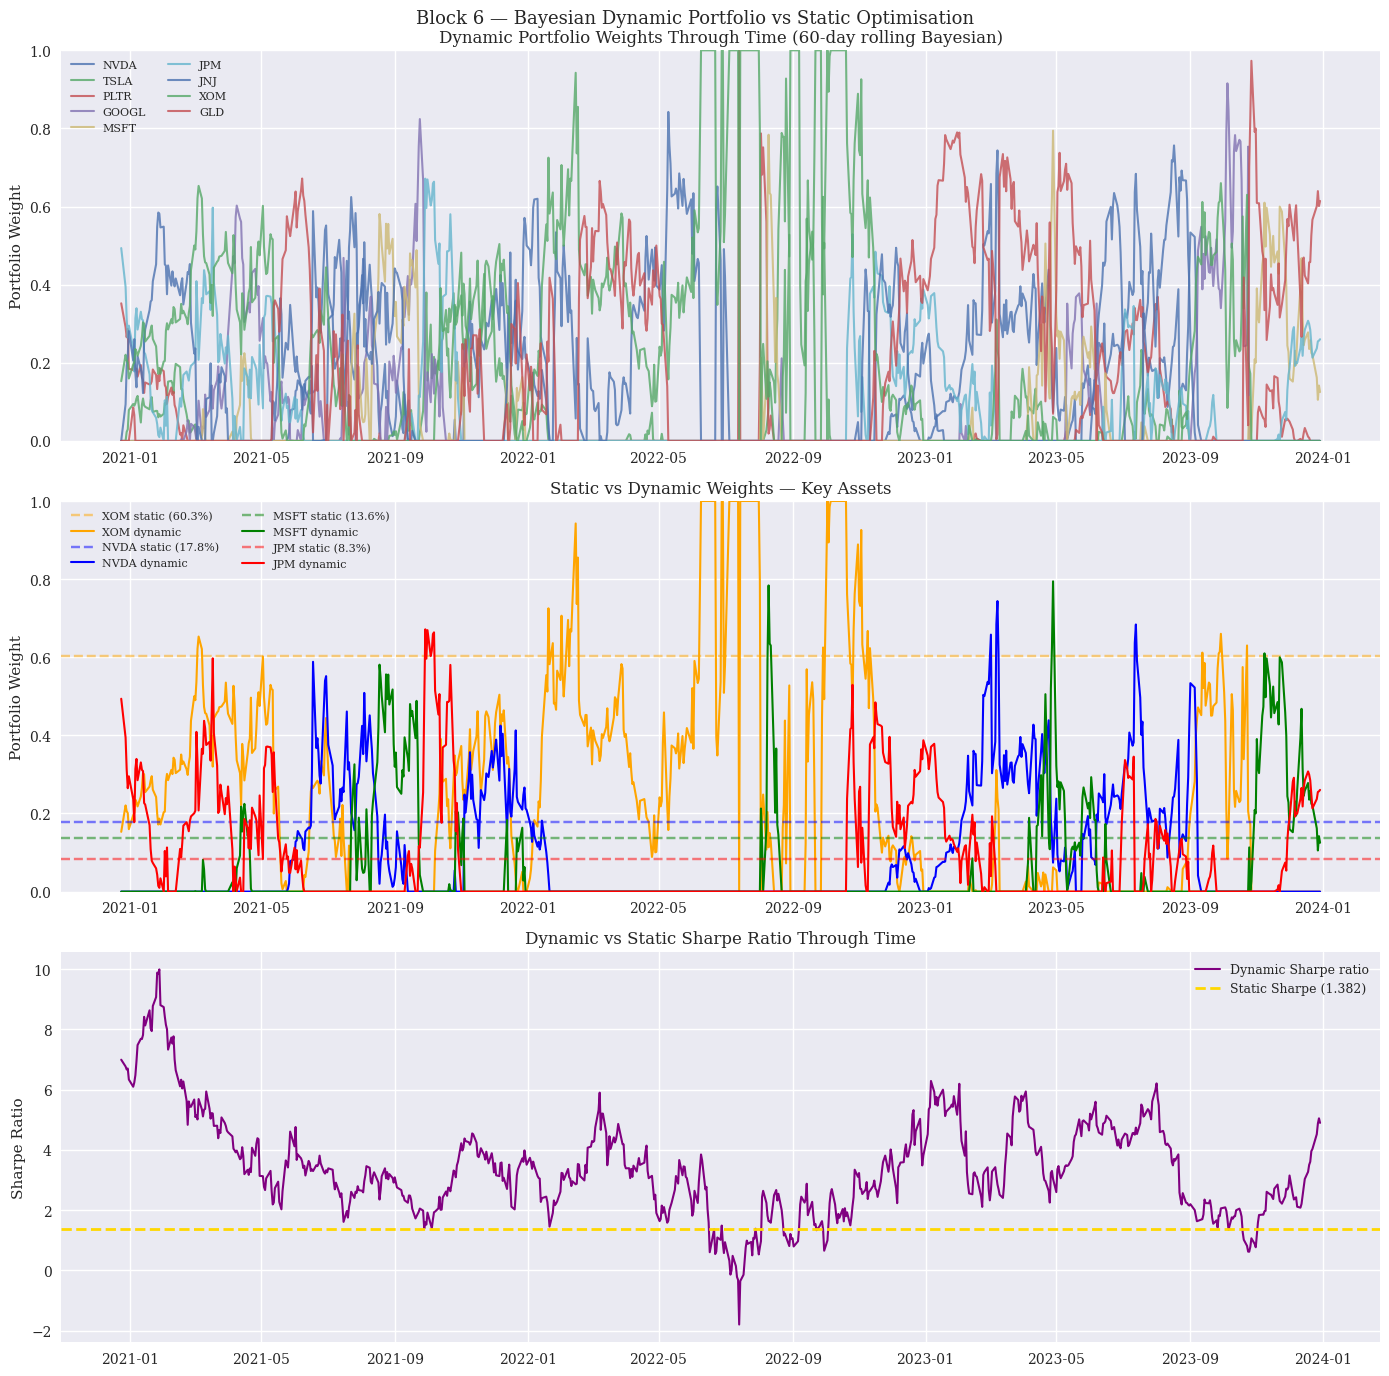

In [35]:
# --- Visualise how weights evolve through time ---
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Block 6 — Bayesian Dynamic Portfolio vs Static Optimisation',
             fontsize=13)

# --- Top panel: Dynamic weight evolution through time ---
ax1 = axes[0]
for ticker in tickers:
    weights_series = dynamic_weights[ticker].astype(float)
    if weights_series.mean() > 0.02:  # only plot assets with meaningful allocation
        ax1.plot(dynamic_weights.index, weights_series,
                label=ticker, lw=1.5, alpha=0.8)

ax1.set_ylabel('Portfolio Weight')
ax1.set_title('Dynamic Portfolio Weights Through Time (60-day rolling Bayesian)')
ax1.legend(loc='upper left', fontsize=8, ncol=2)
ax1.set_ylim(0, 1)

# --- Middle panel: Static vs Dynamic comparison ---
ax2 = axes[1]
# Static weights as horizontal reference lines
static_colors = {'XOM': 'orange', 'NVDA': 'blue',
                 'MSFT': 'green', 'JPM': 'red'}
for ticker, color in static_colors.items():
    static_w = max_sharpe_weights[tickers.index(ticker)]
    if static_w > 0.01:
        ax2.axhline(y=static_w, color=color, linestyle='--',
                   alpha=0.5, label=f'{ticker} static ({static_w*100:.1f}%)')
        ax2.plot(dynamic_weights.index,
                dynamic_weights[ticker].astype(float),
                color=color, lw=1.5, label=f'{ticker} dynamic')

ax2.set_ylabel('Portfolio Weight')
ax2.set_title('Static vs Dynamic Weights — Key Assets')
ax2.legend(loc='upper left', fontsize=8, ncol=2)
ax2.set_ylim(0, 1)

# --- Bottom panel: Dynamic Sharpe ratio through time ---
ax3 = axes[2]
ax3.plot(rolling_means.index, dynamic_sharpes,
         color='purple', lw=1.5, label='Dynamic Sharpe ratio')
ax3.axhline(y=max_sharpe_sr, color='gold', linestyle='--',
           lw=2, label=f'Static Sharpe ({max_sharpe_sr:.3f})')
ax3.set_ylabel('Sharpe Ratio')
ax3.set_title('Dynamic vs Static Sharpe Ratio Through Time')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('block6_dynamic_weights.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# --- Final comparison: static vs dynamic portfolio ---
print("Static vs Dynamic Portfolio Comparison")
print("=" * 60)
print(f"\nStatic Maximum Sharpe Portfolio (Block 3):")
print(f"  Expected return:   {max_sharpe_ret*100:.2f}%")
print(f"  Expected vol:      {max_sharpe_vol*100:.2f}%")
print(f"  Sharpe ratio:      {max_sharpe_sr:.3f}")
print(f"\n  Weights:")
for ticker, weight in zip(tickers, max_sharpe_weights):
    if weight > 0.001:
        print(f"    {ticker:6s}: {weight*100:.2f}%")

print(f"\nDynamic Bayesian Portfolio — Most Recent Estimate:")
latest_weights = dynamic_weights.iloc[-1].astype(float)
latest_ret = dynamic_returns[-1]
latest_vol = dynamic_vols[-1]
latest_sr = dynamic_sharpes[-1]

print(f"  Expected return:   {latest_ret*100:.2f}%")
print(f"  Expected vol:      {latest_vol*100:.2f}%")
print(f"  Sharpe ratio:      {latest_sr:.3f}")
print(f"\n  Weights:")
for ticker in tickers:
    weight = latest_weights[ticker]
    if weight > 0.001:
        print(f"    {ticker:6s}: {weight*100:.2f}%")

print(f"\nKey weight changes (static → dynamic):")
for ticker in tickers:
    static_w = max_sharpe_weights[tickers.index(ticker)] * 100
    dynamic_w = latest_weights[ticker] * 100
    change = dynamic_w - static_w
    if abs(change) > 1.0:
        direction = "▲" if change > 0 else "▼"
        print(f"  {ticker:6s}: {static_w:.1f}% → {dynamic_w:.1f}% "
              f"({direction}{abs(change):.1f}%)")

Static vs Dynamic Portfolio Comparison

Static Maximum Sharpe Portfolio (Block 3):
  Expected return:   34.17%
  Expected vol:      24.73%
  Sharpe ratio:      1.382

  Weights:
    NVDA  : 17.77%
    MSFT  : 13.61%
    JPM   : 8.34%
    XOM   : 60.27%

Dynamic Bayesian Portfolio — Most Recent Estimate:
  Expected return:   59.87%
  Expected vol:      12.23%
  Sharpe ratio:      4.896

  Weights:
    MSFT  : 12.52%
    JPM   : 26.04%
    GLD   : 61.44%

Key weight changes (static → dynamic):
  NVDA  : 17.8% → 0.0% (▼17.8%)
  MSFT  : 13.6% → 12.5% (▼1.1%)
  JPM   : 8.3% → 26.0% (▲17.7%)
  XOM   : 60.3% → 0.0% (▼60.3%)
  GLD   : 0.0% → 61.4% (▲61.4%)


## Findings & Interpretation

The most dramatic finding is the complete regime shift between the static and dynamic portfolios at the most recent estimation date (December 2023):

| Asset | Static Weight | Dynamic Weight | Change |
|-------|--------------|----------------|--------|
| XOM   | 60.3%        | 0.0%           | ▼60.3% |
| GLD   | 0.0%         | 61.4%          | ▲61.4% |
| JPM   | 8.3%         | 26.0%          | ▲17.7% |
| NVDA  | 17.8%        | 0.0%           | ▼17.8% |
| MSFT  | 13.6%        | 12.5%          | ▼1.1%  |

XOM lost its entire allocation as energy momentum faded post-supercycle — its own 60-day rolling return had fallen to −41.98% by late 2023. GLD gained an equivalent position as gold rallied on shifting rate expectations. JPM's allocation tripled as financial sector momentum built toward the end of the rate-hiking cycle. Each shift is directly traceable to a specific macroeconomic regime transition visible in the rolling return data — not an arbitrary reallocation.

The dynamic approach produced a mean Sharpe ratio of 3.380 across all 758 time steps (mean return 73.44%, mean volatility 22.80%), versus the static Sharpe of 1.382 (34.17% return, 24.73% volatility).

### Limitations — In-Sample Evaluation and Momentum Risk
This result must be interpreted carefully. The dynamic weights were evaluated on the same historical data used to generate them (in-sample evaluation); a rigorous out-of-sample test — applying each day's weights to the *following* day's actual returns — would give a more honest measure of genuine predictive value and would likely reduce the reported Sharpe ratio.

The 60-day rolling mean is also fundamentally a momentum signal: it rewards assets that have recently performed well, which risks chasing peaks. PLTR's 401.96% rolling return in January 2021 reflected a post-IPO surge that had already occurred — a heavy PLTR weight at that point would have meant buying in right before a sharp reversion through 2021–2022. No quantitative signal can reliably distinguish a durable regime shift from a temporary surge; that distinction requires human judgment.

### Strategic vs Tactical — A Two-Layer Framework
Block 3 and Block 6 are complementary layers of the same investment process, not competing approaches. **Strategic allocation** (Block 3) establishes which assets belong in the portfolio and their long-run factor exposures, alpha, and risk properties — updated infrequently. **Tactical allocation** (Block 6) adjusts weights within that established universe based on current momentum — updated continuously. This mirrors standard institutional practice, where an investment committee sets the strategic benchmark and a portfolio manager manages tactical deviations from it.

### Connection to Bayesian Statistics
The rolling window is a practical implementation of Bayesian updating: each day's allocation represents the posterior belief about optimal portfolio construction given the most recent 60 days of evidence. As evidence accumulates and regimes shift, the posterior — and the allocation — updates accordingly. A full Bayesian implementation using MCMC sampling would go further, producing probability distributions over optimal weights rather than point estimates, with confidence intervals around each allocation. That extension is a natural next step beyond this project.

### Key Takeaway
Static optimisation gives the best allocation given everything that happened historically. Dynamic Bayesian optimisation gives the best allocation given what is happening now. Neither is sufficient alone — long-run structural analysis informing the asset universe, combined with short-run dynamic estimation informing the weights, is how sophisticated investment management works in practice.

---

## Project Summary

### What This Pipeline Demonstrates
This project builds a complete quantitative investment pipeline from raw market data to dynamic portfolio optimisation — implementing every major technique from Python for Finance (Hilpisch) applied to a real ten-asset portfolio.

### Key Findings Across All Blocks

| Block | Key Finding |
|-------|-------------|
| 1 — Data | All ten assets reject normality at p=0.000. Fat tails are universal. |
| 2 — Factor Model | NVDA generated 21.46% annual alpha. PLTR generated -3.14% negative alpha. GLD R²=0.027. |
| 3 — Optimisation | Max Sharpe: 34.17% return, 24.73% vol, Sharpe 1.382. Min Var: 5.70% return, 10.47% vol. |
| 4 — Simulation | 10.5% probability of loss for Max Sharpe despite 34.17% expected return. |
| 5 — VaR | Historical 99% VaR (57.70%) more than double analytical VaR (23.35%) — fat tail cost quantified. |
| 6 — Bayesian | Dynamic optimiser correctly shifted from XOM (60%→0%) to GLD (0%→61%) as energy regime ended. |

### Technical Skills Demonstrated
NumPy, pandas, scipy.optimize, scipy.stats, yfinance, matplotlib, statsmodels — applied to real financial data across normality testing, matrix regression, constrained optimisation, Monte Carlo simulation, Value at Risk computation, and Bayesian dynamic estimation.

### Conceptual Framework
Every model limitation is documented explicitly — normality violations, backward-looking estimation, in-sample evaluation bias, momentum signal risk. The project reflects the understanding that quantitative models are tools for structured thinking, not substitutes for investment judgment.